# 01d. BAMIC on Wine Reviews: gate-calibrated selected-token normalization

This notebook is the **gate-recovery successor** to
`01c_bamic_wine_posenc_selnorm_bestval.ipynb`. The completed `01c` notebook and
its Drive artifacts remain unchanged so the collapsed-gate result stays
reproducible. Run this notebook top-to-bottom in a fresh Google Colab GPU
runtime.

## Why `01c` needs a new run

With selected-token normalization, multiplying every gate by nearly the same
small constant barely changes the document prediction because the constant
appears in both numerator and denominator. In `01c`, the global sparsity term
therefore rewarded shrinking every gate, and the squared 5% floor was too weak
to oppose it. The saved Wine run reached a mean gate rate of only about 0.55%,
so its accuracy was usable but its gate was not a credible selector.

## What changes in this variant

1. **Keep positional encoding and selected-token normalization.** These were
   performance improvements and are not the cause of the gate collapse.
2. **Remove the global `P2` sparsity penalty in normalized mode.** It remains
   available only in the optional legacy-aggregation ablation.
3. **Replace the squared floor with a strong per-document linear rate band.**
   The default 7.5%–12.5% band is centered at a 10% evidence budget—about three
   soft-selected tokens for the observed average Wine review length.
4. **Retain `P1` for gate polarization.** The strong rate band prevents the
   collapse direction, while `P1` favors differentiated gates instead of a
   uniform 0.10 score on every token.
5. **Make gate health part of validation checkpoint eligibility.** A checkpoint
   must pass validation-only rate and contrast checks before NLL can select it.
   If no healthy checkpoint exists, the notebook stops before opening test data.
6. **Parameterize matched seeds and a checkpoint-only legacy ablation.** Each
   run writes to a distinct Drive folder containing the mode, seed, and run label.

## Interpretation boundary

`delta` remains a learned **soft gate score**, not a calibrated probability that
a token belongs to a human rationale. Passing the rate and contrast checks makes
the selector non-collapsed and differentiated; it does not establish token-level
calibration without rationale labels.

## Evaluation-status boundary

This rerun is **exploratory**, not a new confirmatory test. We already inspected
the existing `wine_test.csv` results when diagnosing `01c`, so that project-level
holdout is no longer blind to this redesign. This notebook still prevents any
within-run test leakage, which makes it suitable for comparison and debugging.
For a final unbiased paper claim, use a newly reserved blind holdout or nested
cross-validation after freezing this design and its gate-health rules.

In [1]:
# ================================================================
# 0. Check the Colab GPU
# ================================================================

# Ask the Colab runtime which GPU we were given.
gpu_info = !nvidia-smi
# Join the command output lines into one printable string.
gpu_info = '\n'.join(gpu_info)
# If the command failed, we are not connected to a GPU runtime.
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU. In Colab: Runtime -> Change runtime type -> T4 GPU.')
else:
    print(gpu_info)

Wed Aug  5 17:53:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             56W /  400W |     900MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# ================================================================
# 1. Check the Colab RAM
# ================================================================

# psutil reports how much system memory this runtime has.
import psutil
# Convert bytes to gigabytes for a readable number.
ram_gb = psutil.virtual_memory().total / 1e9
# Print the available RAM so we know which runtime type we received.
print('Your runtime has {:.1f} gigabytes of available RAM'.format(ram_gb))

Your runtime has 179.4 gigabytes of available RAM


In [3]:
# ================================================================
# 2. Basic imports and reproducibility
# ================================================================

from pathlib import Path
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss, log_loss
import matplotlib.pyplot as plt
import math

# Five seeds are preregistered here so upgraded and legacy-ablation runs can use
# exactly the same randomness. Run one seed at a time in a fresh Colab runtime.
MATCHED_SEED_PLAN = [20260526, 20260527, 20260528, 20260529, 20260530]

# Change only this value for the next matched-seed run.
RUN_SEED = 20260526
if RUN_SEED not in MATCHED_SEED_PLAN:
    raise ValueError(f'RUN_SEED must be one of the preregistered seeds: {MATCHED_SEED_PLAN}')
SEED = int(RUN_SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# These settings remove a common source of run-to-run CUDA variation. Exact bitwise
# identity can still depend on the Colab GPU model and PyTorch/CUDA version, so the
# environment is saved later alongside the run configuration.
if hasattr(torch.backends, 'cudnn'):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
print('RUN_SEED:', RUN_SEED)
print('MATCHED_SEED_PLAN:', MATCHED_SEED_PLAN)

Using device: cuda
RUN_SEED: 20260526
MATCHED_SEED_PLAN: [20260526, 20260527, 20260528, 20260529, 20260530]


## Step 1 — Lock the gate-recovery experiment before training

The default mode is the repaired position-aware, selected-token-normalized
model. The same notebook also exposes a `checkpoint_only_legacy` mode for a
matched ablation. Change the mode or seed only before a fresh top-to-bottom run;
the output-folder guard prevents stale checkpoints from being mixed together.

In [4]:
# ================================================================
# 3. BAMIC configuration for this run (review this entire cell)
# ================================================================

# DEFAULT: repaired selector with positions and selected-token normalization.
# OPTIONAL ABLATION: original aggregation/objective plus clean checkpointing only.
RUN_MODE = 'gate_calibrated_selnorm'
VALID_RUN_MODES = {'gate_calibrated_selnorm', 'checkpoint_only_legacy'}
if RUN_MODE not in VALID_RUN_MODES:
    raise ValueError(f'RUN_MODE must be one of {sorted(VALID_RUN_MODES)}')

# Increment this label only when intentionally repeating the same mode and seed.
RUN_LABEL = 'v1'

FREEZE_EMBEDDINGS = True
ABLATION_EPOCHS = 15
NUM_HEADS = 1

# Wine-specific penalties inherited unchanged from the comparable Wine BAMIC run.
USE_BOILERPLATE_PENALTY = True
LAMBDA_BOILERPLATE = 0.10
USE_STOPWORD_SELECTION_PENALTY = True
LAMBDA_STOPWORD = 0.01
STOPWORD_PENALTY_EXCLUDES_BOILERPLATE = True
STOPWORD_WARMUP_EPOCHS = 2

BAMIC_LEARNING_RATE = 3e-4
MAX_LEN = 100
BATCH_SIZE = 128
POSITION_ENCODING_TYPE = 'learned_absolute'
AGGREGATION_EPS = 1e-6

# Legacy BAMIC regularizers. P1 polarizes the gate. P2 rewards small global gate
# mass and is mathematically incompatible with selected-token normalization.
LAMBDA_P1 = 0.01
LEGACY_LAMBDA_P2 = 0.01
LAMBDA_P3 = 0.001

# ------------------------------------------------------------------
# Gate recovery constraint (declared before seeing this run's validation result)
# ------------------------------------------------------------------
# The previous mean rate was ~0.0055. A 10% center leaves a safety margin above
# the 5% collapse boundary and represents roughly three soft-selected tokens for
# an average Wine review. Later sensitivity runs can compare 5%, 10%, and 15%.
SELECTION_RATE_BAND_CENTER = 0.10
SELECTION_RATE_BAND_LOW = 0.075
SELECTION_RATE_BAND_HIGH = 0.125
LAMBDA_SELECTION_RATE_BAND = 1.0

# Validation-only checkpoint health rules. The training band is deliberately
# narrower than this safety envelope so ordinary stochastic variation is allowed.
GATE_HEALTH_MEAN_RATE_LOW = 0.05
GATE_HEALTH_MEAN_RATE_HIGH = 0.15
GATE_HEALTH_MIN_DOCUMENT_RATE = 0.05
GATE_HEALTH_MAX_FRACTION_DOCS_BELOW_MIN = 0.10
GATE_HEALTH_MAX_DOCUMENT_RATE = 0.15
GATE_HEALTH_MAX_FRACTION_DOCS_ABOVE_MAX = 0.10
GATE_CONTRAST_MIN_LENGTH = 4
GATE_HEALTH_MIN_MEDIAN_CONTRAST_RATIO = 1.50

# Clean validation checkpointing. Epochs 1-2 use penalty warmup, so they cannot
# become the final checkpoint. Patience starts only after a healthy checkpoint exists.
CHECKPOINT_METRIC = 'nll'
CHECKPOINT_MIN_DELTA = 1e-4
CHECKPOINT_START_EPOCH = STOPWORD_WARMUP_EPOCHS + 1
EARLY_STOPPING_PATIENCE = 4
MIN_EPOCHS_BEFORE_EARLY_STOPPING = 8

valid_checkpoint_metrics = {'nll', 'brier', 'acc', 'auc'}
if CHECKPOINT_METRIC not in valid_checkpoint_metrics:
    raise ValueError(f'CHECKPOINT_METRIC must be one of {valid_checkpoint_metrics}')
CHECKPOINT_MODE = 'min' if CHECKPOINT_METRIC in {'nll', 'brier'} else 'max'

if not (0.0 < SELECTION_RATE_BAND_LOW < SELECTION_RATE_BAND_CENTER
        < SELECTION_RATE_BAND_HIGH < 1.0):
    raise ValueError('Selection-rate band must contain its center and lie inside (0, 1).')
if not np.isclose(
    SELECTION_RATE_BAND_CENTER,
    0.5 * (SELECTION_RATE_BAND_LOW + SELECTION_RATE_BAND_HIGH),
):
    raise ValueError('SELECTION_RATE_BAND_CENTER must equal the midpoint of the band.')

if RUN_MODE == 'gate_calibrated_selnorm':
    USE_POSITIONAL_ENCODING = True
    AGGREGATION_MODE = 'selected_token_mean'
    USE_SELECTION_RATE_BAND = True
    USE_GATE_VALID_CHECKPOINT = True
    # Critical fix: no global sparsity reward when delta appears in both numerator
    # and denominator. P1 remains active to favor a non-uniform, polarized selector.
    LAMBDA_P2 = 0.0
    variant_tag = 'gatefix_rate0p075to0p125_posenc_selnorm_gatevalid'
else:
    # Controlled ablation: reproduce the legacy model/objective and change only
    # validation checkpointing/holdout discipline.
    USE_POSITIONAL_ENCODING = False
    AGGREGATION_MODE = 'token_mean'
    USE_SELECTION_RATE_BAND = False
    USE_GATE_VALID_CHECKPOINT = False
    LAMBDA_P2 = LEGACY_LAMBDA_P2
    variant_tag = 'checkpointonly_legacy'

freeze_tag = 'frozen' if FREEZE_EMBEDDINGS else 'unfrozen'
EXPERIMENT_NAME = (
    f'wine_bamic_{variant_tag}_bestval_{freeze_tag}'
    f'_ep{ABLATION_EPOCHS}_heads{NUM_HEADS}'
    f'_lamB{str(LAMBDA_BOILERPLATE).replace(".", "p")}'
    f'_lamS{str(LAMBDA_STOPWORD).replace(".", "p")}'
    f'_len{MAX_LEN}_seed{SEED}_{RUN_LABEL}'
)

print('RUN_MODE                :', RUN_MODE)
print('RUN_SEED / RUN_LABEL    :', RUN_SEED, '/', RUN_LABEL)
print('FREEZE_EMBEDDINGS       :', FREEZE_EMBEDDINGS)
print('ABLATION_EPOCHS         :', ABLATION_EPOCHS)
print('NUM_HEADS               :', NUM_HEADS)
print('LAMBDA_BOILERPLATE      :', LAMBDA_BOILERPLATE)
print('LAMBDA_STOPWORD         :', LAMBDA_STOPWORD)
print('STOPWORD_WARMUP_EPOCHS  :', STOPWORD_WARMUP_EPOCHS)
print('BAMIC_LEARNING_RATE     :', BAMIC_LEARNING_RATE)
print('MAX_LEN / BATCH_SIZE    :', MAX_LEN, '/', BATCH_SIZE)
print('POSITION_ENCODING       :', POSITION_ENCODING_TYPE, '| enabled:', USE_POSITIONAL_ENCODING)
print('AGGREGATION_MODE        :', AGGREGATION_MODE)
print('LAMBDA_P1 / P2 / P3     :', LAMBDA_P1, '/', LAMBDA_P2, '/', LAMBDA_P3)
print('SELECTION_RATE_BAND     :', (SELECTION_RATE_BAND_LOW, SELECTION_RATE_BAND_HIGH),
      '| lambda:', LAMBDA_SELECTION_RATE_BAND, '| enabled:', USE_SELECTION_RATE_BAND)
print('GATE CHECKPOINT         :', USE_GATE_VALID_CHECKPOINT,
      '| mean-rate envelope:', (GATE_HEALTH_MEAN_RATE_LOW, GATE_HEALTH_MEAN_RATE_HIGH),
      '| max low/high document fractions:',
      (GATE_HEALTH_MAX_FRACTION_DOCS_BELOW_MIN, GATE_HEALTH_MAX_FRACTION_DOCS_ABOVE_MAX),
      '| min contrast:', GATE_HEALTH_MIN_MEDIAN_CONTRAST_RATIO)
print('CHECKPOINT_METRIC       :', CHECKPOINT_METRIC, '| mode:', CHECKPOINT_MODE)
print('CHECKPOINT_START_EPOCH  :', CHECKPOINT_START_EPOCH)
print('EARLY_STOPPING_PATIENCE :', EARLY_STOPPING_PATIENCE,
      '| earliest stop:', MIN_EPOCHS_BEFORE_EARLY_STOPPING)
print('EXPERIMENT_NAME         :', EXPERIMENT_NAME)

RUN_MODE                : gate_calibrated_selnorm
RUN_SEED / RUN_LABEL    : 20260526 / v1
FREEZE_EMBEDDINGS       : True
ABLATION_EPOCHS         : 15
NUM_HEADS               : 1
LAMBDA_BOILERPLATE      : 0.1
LAMBDA_STOPWORD         : 0.01
STOPWORD_WARMUP_EPOCHS  : 2
BAMIC_LEARNING_RATE     : 0.0003
MAX_LEN / BATCH_SIZE    : 100 / 128
POSITION_ENCODING       : learned_absolute | enabled: True
AGGREGATION_MODE        : selected_token_mean
LAMBDA_P1 / P2 / P3     : 0.01 / 0.0 / 0.001
SELECTION_RATE_BAND     : (0.075, 0.125) | lambda: 1.0 | enabled: True
GATE CHECKPOINT         : True | mean-rate envelope: (0.05, 0.15) | max low/high document fractions: (0.1, 0.1) | min contrast: 1.5
CHECKPOINT_METRIC       : nll | mode: min
CHECKPOINT_START_EPOCH  : 3
EARLY_STOPPING_PATIENCE : 4 | earliest stop: 8
EXPERIMENT_NAME         : wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_v1


## Step 2 — Mount Drive and reserve a new result folder

The folder name includes `gatefix` (or `checkpointonly_legacy`), the seed, and
the run label. The cell refuses to use a non-empty folder by default; this keeps
the collapsed `01c` checkpoint and every rerun as separate evidence.

In [5]:
# ================================================================
# 4. Mount Google Drive and define non-overwriting project paths
# ================================================================

from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

PROJECT_DIR = Path('/content/drive/MyDrive/AMIC project')
BENCH_DIR = PROJECT_DIR / 'wine_benchmark'
DATA_DIR = BENCH_DIR / 'data'
OUTPUT_DIR = BENCH_DIR / 'outputs' / EXPERIMENT_NAME
# Keep the established filename inside the new, collision-proof run folder. Gate
# eligibility and validation provenance are stored inside the checkpoint payload.
BEST_CHECKPOINT_PATH = OUTPUT_DIR / 'best_validation_checkpoint.pt'

# Preserve every completed/partial run. To intentionally repeat the exact mode and
# seed, change RUN_LABEL in the configuration cell instead of enabling overwrite.
ALLOW_EXISTING_NONEMPTY_RUN = False
if OUTPUT_DIR.exists():
    existing_items = list(OUTPUT_DIR.iterdir())
    if existing_items and not ALLOW_EXISTING_NONEMPTY_RUN:
        raise FileExistsError(
            f'Run folder is not empty: {OUTPUT_DIR}. '
            'Change RUN_LABEL (recommended) or RUN_SEED before rerunning.'
        )
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save the matched-seed plan immediately so a Colab disconnect still leaves the
# intended comparison protocol next to any partial history.
pd.DataFrame({
    'seed': MATCHED_SEED_PLAN,
    'run_gate_calibrated_selnorm': True,
    'run_checkpoint_only_legacy': True,
}).to_csv(OUTPUT_DIR / 'matched_seed_plan.csv', index=False)

print('DATA_DIR  :', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('BEST_CHECKPOINT_PATH:', BEST_CHECKPOINT_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
DATA_DIR  : /content/drive/MyDrive/AMIC project/wine_benchmark/data
OUTPUT_DIR: /content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_v1
BEST_CHECKPOINT_PATH: /content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_v1/best_validation_checkpoint.pt


In [6]:
# ================================================================
# 4. Load TRAIN and VALIDATION only
# ================================================================

# Strict holdout rule: the test CSV is intentionally not opened in this cell.
for name in ['wine_train.csv', 'wine_valid.csv']:
    if not (DATA_DIR / name).exists():
        raise FileNotFoundError(
            f'Missing {DATA_DIR / name}. Run 00_prepare_wine_data.ipynb first.'
        )

train_df = pd.read_csv(DATA_DIR / 'wine_train.csv')
valid_df = pd.read_csv(DATA_DIR / 'wine_valid.csv')
for df in [train_df, valid_df]:
    df['text'] = df['text'].astype(str)

print('train:', train_df.shape, '| positive rate:', round(train_df['y'].mean(), 4))
print('valid:', valid_df.shape, '| positive rate:', round(valid_df['y'].mean(), 4))
print(train_df['text'].iloc[0][:300], '...')
print('Test remains unopened until the best validation checkpoint is restored.')

train: (25000, 3) | positive rate: 0.342
valid: (3000, 3) | positive rate: 0.342
Offers a diffuse, medium-bodied mix of cherry cola and pie, with a touch of chicory, turning simpler on the finish. Drink now. 625 cases made. ...
Test remains unopened until the best validation checkpoint is restored.


In [7]:
# ================================================================
# 5. Tokenization, vocabulary, and fixed-length encoding
# ================================================================

# This regular expression keeps word-like tokens, numbers, and contractions
# such as "it's" as single tokens (same tokenizer as the wine and SST-2 notebooks).
TOKEN_RE = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")


def clean_text(text):
    """Convert raw text to a normalized lowercase string."""
    # Guard against missing values.
    if not isinstance(text, str):
        text = ''
    # Lowercase so 'Good' and 'good' share one embedding.
    text = text.lower()
    # Collapse repeated whitespace into single spaces.
    text = re.sub(r'\s+', ' ', text).strip()
    # Return the normalized string.
    return text


def tokenize(text):
    """Tokenize text into a list of lowercase word-like tokens."""
    return TOKEN_RE.findall(clean_text(text))


# MAX_LEN comes from the configuration cell above (100, the original AMIC window,
# which covers every review in this corpus completely).
print('Using MAX_LEN from the configuration cell:', MAX_LEN)

# MIN_FREQ = 2 matches the original wine AMIC/BAMIC notebooks, so the vocabulary
# (and therefore the published wine numbers) stays comparable.
MIN_FREQ = 2

# Count token frequencies over the TRAINING split only (never valid/test, to avoid leakage).
token_counts = Counter()
for text in train_df['text']:
    token_counts.update(tokenize(text))

# Index 0 is reserved for padding; index 1 is reserved for unknown words.
word_to_id = {'<PAD>': 0, '<UNK>': 1}

# Add every frequent-enough token to the vocabulary.
for word, count in token_counts.most_common():
    if count >= MIN_FREQ:
        word_to_id[word] = len(word_to_id)

# Build the reverse map for printing words back from ids.
id_to_word = {idx: word for word, idx in word_to_id.items()}

# Report the vocabulary size and the most common tokens as a sanity check.
print('Vocabulary size including PAD and UNK:', len(word_to_id))
print('Most common tokens:', token_counts.most_common(10))


def encode_text(text):
    """Convert one review into a fixed-length list of token ids."""
    # Map each token to its id, or to UNK when the token is out of vocabulary.
    ids = [word_to_id.get(tok, 1) for tok in tokenize(text)]
    # Truncate reviews that are longer than MAX_LEN.
    ids = ids[:MAX_LEN]
    # Remember the real (unpadded) length.
    length = len(ids)
    # Pad short reviews with zeros up to MAX_LEN.
    ids = ids + [0] * (MAX_LEN - len(ids))
    # Return both the ids and the real length.
    return ids, length


def encode_dataframe(df):
    """Encode a whole dataframe into id matrices, lengths, and label arrays."""
    encoded = [encode_text(t) for t in df['text']]
    x = np.array([e[0] for e in encoded], dtype=np.int64)
    lengths = np.array([e[1] for e in encoded], dtype=np.int64)
    y = df['y'].to_numpy().astype(np.float32)
    return x, lengths, y


# Encode train and validation only. Test encoding is deferred until restoration.
x_train, len_train, y_train = encode_dataframe(train_df)
x_valid, len_valid, y_valid = encode_dataframe(valid_df)

print('Share of train reviews truncated at MAX_LEN:',
      round((len_train == MAX_LEN).mean(), 3))
print('x_train:', x_train.shape, 'y_train:', y_train.shape)
print('x_valid:', x_valid.shape, 'y_valid:', y_valid.shape)

Using MAX_LEN from the configuration cell: 100
Vocabulary size including PAD and UNK: 5210
Most common tokens: [('and', 57996), ('with', 24692), ('cases', 23842), ('a', 23808), ('the', 21999), ('now', 21213), ('drink', 20745), ('made', 18466), ('of', 17692), ('through', 17657)]
Share of train reviews truncated at MAX_LEN: 0.0
x_train: (25000, 100) y_train: (25000,)
x_valid: (3000, 100) y_valid: (3000,)


In [8]:
# ================================================================
# 6. Load GloVe 300d embeddings for our vocabulary
# ================================================================

# GloVe 6B vectors are 300-dimensional, matching the wine BAMIC setup.
EMBED_DIM = 300

# The GloVe text file lives in the shared word_embedding folder of the Drive project.
GLOVE_PATH = PROJECT_DIR / 'word_embedding' / 'glove.6B.300d.txt'

# Fail early with a clear message if the embedding file is missing.
if not GLOVE_PATH.exists():
    raise FileNotFoundError(f'GloVe file not found: {GLOVE_PATH}. '
                            'Upload glove.6B.300d.txt to the word_embedding folder in Drive.')


def build_random_embedding_matrix(vocab_size, embedding_dim):
    """Create a small random embedding matrix with a zero padding row."""
    # A fixed-seed generator keeps the random rows reproducible.
    rng = np.random.default_rng(SEED)
    # Small random values for words that GloVe does not cover.
    matrix = rng.normal(loc=0.0, scale=0.05, size=(vocab_size, embedding_dim)).astype(np.float32)
    # Row 0 is the PAD token and must stay all-zero.
    matrix[0] = 0.0
    # Return the initialized matrix.
    return matrix


def load_glove_for_vocab(glove_path, word_to_id, embedding_dim=300):
    """Load only the GloVe vectors whose words appear in our vocabulary."""
    # Start from the random matrix so uncovered words keep small random vectors.
    matrix = build_random_embedding_matrix(len(word_to_id), embedding_dim)
    # Track how many vocabulary words GloVe covers.
    found = 0
    # A set makes the membership test fast inside the file loop.
    needed_words = set(word_to_id.keys())
    # Stream the large GloVe file line by line to stay memory-friendly.
    with open(glove_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            # Each line is: word value_1 ... value_300.
            parts = line.rstrip().split(' ')
            # Skip malformed lines defensively.
            if len(parts) != embedding_dim + 1:
                continue
            # First field is the word itself.
            word = parts[0]
            # Ignore words that are not in our vocabulary.
            if word not in needed_words:
                continue
            # Copy this word's vector into its row of the matrix.
            matrix[word_to_id[word]] = np.asarray(parts[1:], dtype=np.float32)
            # Count the successful match.
            found += 1
    # Keep the PAD row exactly zero after loading.
    matrix[0] = 0.0
    # Report the coverage so we can compare with the wine corpus (92.7% there).
    print(f'Loaded {found:,} / {len(word_to_id):,} vocabulary vectors from GloVe '
          f'({found / max(1, len(word_to_id)):.1%}).')
    # Return the matrix as a torch tensor ready for nn.Embedding.
    return torch.tensor(matrix, dtype=torch.float32)


# Build the embedding matrix for this vocabulary.
embedding_matrix = load_glove_for_vocab(GLOVE_PATH, word_to_id, EMBED_DIM)

# Confirm the final shape: (vocabulary size, embedding dimension).
print('embedding_matrix:', tuple(embedding_matrix.shape))

Loaded 4,988 / 5,210 vocabulary vectors from GloVe (95.7%).
embedding_matrix: (5210, 300)


In [9]:
# ================================================================
# 8. Stopword and boilerplate penalty masks (wine-specific)
# ================================================================

# Common English function words that should not dominate word-level sentiment
# explanations - the SAME conservative list as the original wine notebook
# (no contraction fragments needed: the tokenizer keeps "it's" as one token).
STOPWORD_PENALTY_WORDS = {
    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'then', 'else', 'when', 'while',
    'as', 'of', 'in', 'on', 'at', 'by', 'for', 'from', 'to', 'into', 'onto',
    'with', 'without', 'within', 'over', 'under', 'above', 'below', 'up', 'down',
    'out', 'off', 'through', 'during', 'before', 'after', 'between', 'among',
    'about', 'against', 'this', 'that', 'these', 'those', 'there', 'here',
    'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
    'do', 'does', 'did', 'can', 'could', 'should', 'would', 'will', 'may',
    'might', 'must', 'not', 'no', 'nor', 'so', 'than', 'too', 'very', 'some',
    'any', 'all', 'each', 'few', 'more', 'most', 'other', 'such', 'only',
    'own', 'same', 'both', 'either', 'neither', 'it', 'its', 'itself', 'they',
    'them', 'their', 'theirs', 'he', 'him', 'his', 'she', 'her', 'hers', 'we',
    'us', 'our', 'ours', 'you', 'your', 'yours', 'i', 'me', 'my', 'mine',
    'who', 'whom', 'whose', 'which', 'what', 'where', 'why', 'how', 'because',
    'also', 'just', 'even', 'still', 'already', 'yet', 'now',
}

# These patterns match ONLY trailing wine-review metadata, applied repeatedly from
# the end of the review - "drink" inside a real sentence is never touched.
# (Identical to the original Bayesian_AMIC_WD_clean notebook.)
WINE_TRAILING_BOILERPLATE_PATTERNS = [
    # Trailing production/import metadata, e.g. "1,200 cases made, 300 cases imported."
    re.compile(r"\s*\d[\d,]*\s+cases\s+(?:made|imported)"
               r"(?:,\s*\d[\d,]*\s+cases\s+(?:made|imported))*\.?\s*$", flags=re.I),
    # Trailing tasting-note metadata.
    re.compile(r"\s*tasted twice,\s*with consistent notes\.?\s*$", flags=re.I),
    # Trailing drinking-window metadata.
    re.compile(r"\s*(?:drink now|drink now through \d{4}|drink through \d{4}|"
               r"best from \d{4} through \d{4}|from \d{4} through \d{4})\.?\s*$", flags=re.I),
]


def sentiment_token_count(text):
    """Number of leading tokens that are real sentiment text (the rest is boilerplate)."""
    # Normalize exactly like the tokenizer does.
    lowered = clean_text(text)
    # Strip trailing metadata patterns repeatedly until nothing more matches.
    stripped = lowered
    changed = True
    while changed:
        changed = False
        for pattern in WINE_TRAILING_BOILERPLATE_PATTERNS:
            new_text = pattern.sub('', stripped).strip()
            if new_text != stripped:
                stripped = re.sub(r'\s+', ' ', new_text).strip()
                changed = True
    # The boilerplate is whatever tokens remain AFTER the stripped prefix.
    return len(tokenize(stripped))


def build_penalty_masks(df, x_ids):
    """Build aligned stopword and boilerplate 0/1 masks for one split."""
    sw = np.zeros_like(x_ids, dtype=np.float32)
    bp = np.zeros_like(x_ids, dtype=np.float32)
    # Walk over every review in the dataframe.
    for i, text in enumerate(df['text']):
        # Tokens kept by the model are the first MAX_LEN tokens of the full text.
        n_sentiment = sentiment_token_count(text)
        for j in range(x_ids.shape[1]):
            # Token id 0 is padding; padding only appears at the end, so stop there.
            if x_ids[i, j] == 0:
                break
            word = id_to_word.get(int(x_ids[i, j]), '')
            # Positions past the sentiment prefix are trailing boilerplate.
            if j >= n_sentiment:
                bp[i, j] = 1.0
            # Stopword positions (boilerplate wins when both apply - handled in the loss).
            elif word in STOPWORD_PENALTY_WORDS:
                sw[i, j] = 1.0
    return sw, bp


# Build penalty masks for model-development splits only.
sw_train, bp_train = build_penalty_masks(train_df, x_train)
sw_valid, bp_valid = build_penalty_masks(valid_df, x_valid)

for name, sw, bp in [('train', sw_train, bp_train),
                     ('valid', sw_valid, bp_valid)]:
    print(f'{name}: stopword positions={int(sw.sum()):,} | '
          f'boilerplate positions={int(bp.sum()):,}')

train: stopword positions=218,985 | boilerplate positions=167,940
valid: stopword positions=26,442 | boilerplate positions=20,014


In [10]:
# ================================================================
# 9. Dataset and deterministic DataLoaders (three masks per review)
# ================================================================

class AMICTextDataset(Dataset):
    """Dataset wrapper: token ids, label, length, stopword mask, boilerplate mask."""

    def __init__(self, x, y, lengths, stopword_masks, boilerplate_masks):
        self.x = torch.tensor(x, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.stopword_masks = torch.tensor(stopword_masks, dtype=torch.float32)
        self.boilerplate_masks = torch.tensor(boilerplate_masks, dtype=torch.float32)

    def __len__(self):
        return self.x.size(0)

    def __getitem__(self, idx):
        return {
            'input_ids': self.x[idx],
            'label': self.y[idx],
            'length': self.lengths[idx],
            'stopword_mask': self.stopword_masks[idx],
            'boilerplate_mask': self.boilerplate_masks[idx],
        }


print('Using BATCH_SIZE from the configuration cell:', BATCH_SIZE)
train_ds = AMICTextDataset(x_train, y_train, len_train, sw_train, bp_train)
valid_ds = AMICTextDataset(x_valid, y_valid, len_valid, sw_valid, bp_valid)

# Use the same global seeded DataLoader behavior as the legacy Wine notebook. This
# matters for the checkpoint-only ablation: a new sampler generator would make it
# differ from legacy training for a reason unrelated to checkpoint selection.
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
train_eval_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
valid_loader = DataLoader(
    valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print('train batches:', len(train_loader),
      '| train-eval batches:', len(train_eval_loader))
print('valid batches:', len(valid_loader))

Using BATCH_SIZE from the configuration cell: 128
train batches: 196 | train-eval batches: 196
valid batches: 24


In [11]:
# ================================================================
# 9. Bayesian linear layer for b and beta (identical to the wine notebook)
# ================================================================

class BayesianLinear(nn.Module):
    """Linear layer with a factorized Gaussian variational posterior."""

    def __init__(self, in_features, out_features=1, prior_sigma=1.0, init_rho=-5.0):
        # Initialize nn.Module.
        super().__init__()
        # Save dimensions.
        self.in_features = in_features
        self.out_features = out_features
        # Learn posterior means for weights.
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        # Learn unconstrained posterior rho values for weights.
        self.weight_rho = nn.Parameter(torch.full((out_features, in_features), float(init_rho)))
        # Learn posterior means for biases.
        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        # Learn unconstrained posterior rho values for biases.
        self.bias_rho = nn.Parameter(torch.full((out_features,), float(init_rho)))
        # Store the prior standard deviation as a non-trainable tensor.
        self.register_buffer('prior_sigma', torch.tensor(float(prior_sigma)))
        # Initialize means with small noise so b and beta can learn immediately.
        nn.init.normal_(self.weight_mu, mean=0.0, std=0.02)
        # Keep bias means at zero.
        nn.init.zeros_(self.bias_mu)

    @property
    def weight_sigma(self):
        # Convert rho to a positive standard deviation with softplus.
        return F.softplus(self.weight_rho) + 1e-8

    @property
    def bias_sigma(self):
        # Convert rho to a positive standard deviation with softplus.
        return F.softplus(self.bias_rho) + 1e-8

    def sample_parameters(self, sample=True):
        """Return one sampled weight and bias, or the posterior means."""
        # Use posterior means for deterministic evaluation when sample=False.
        if not sample:
            return self.weight_mu, self.bias_mu
        # Draw standard normal noise for weights.
        eps_w = torch.randn_like(self.weight_mu)
        # Draw standard normal noise for biases.
        eps_b = torch.randn_like(self.bias_mu)
        # Reparameterize weights: w = mu + sigma * eps.
        weight = self.weight_mu + self.weight_sigma * eps_w
        # Reparameterize biases the same way.
        bias = self.bias_mu + self.bias_sigma * eps_b
        # Return the sampled parameters.
        return weight, bias

    def forward(self, x, sample=True):
        """Apply the sampled (or mean) linear map to x."""
        # x can have shape [B, D] or [B, T, D].
        weight, bias = self.sample_parameters(sample=sample)
        # F.linear supports leading dimensions automatically.
        return F.linear(x, weight, bias)

    def kl(self):
        """Closed-form KL divergence KL(q(w)||p(w)) for normal q and normal prior."""
        # Get the posterior standard deviations.
        w_sigma = self.weight_sigma
        b_sigma = self.bias_sigma
        # Get the prior standard deviation.
        p_sigma = self.prior_sigma
        # KL contribution of every weight.
        kl_w = torch.log(p_sigma / w_sigma) + (w_sigma.pow(2) + self.weight_mu.pow(2)) / (2.0 * p_sigma.pow(2)) - 0.5
        # KL contribution of every bias.
        kl_b = torch.log(p_sigma / b_sigma) + (b_sigma.pow(2) + self.bias_mu.pow(2)) / (2.0 * p_sigma.pow(2)) - 0.5
        # Sum over all parameters.
        return kl_w.sum() + kl_b.sum()

In [12]:
# ================================================================
# 10. Self-attention block (identical to the wine notebook)
# ================================================================

class SelfAttention(nn.Module):
    """Multi-head self-attention with an optional output projection."""

    def __init__(self, emb_dim, num_heads=1, output_dim=None, dropout=0.10):
        # Initialize nn.Module.
        super().__init__()
        # The embedding dimension must divide evenly across heads.
        assert emb_dim % num_heads == 0, 'emb_dim must be divisible by num_heads'
        # Store dimensions.
        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads
        # Project inputs to queries.
        self.to_q = nn.Linear(emb_dim, emb_dim, bias=False)
        # Project inputs to keys.
        self.to_k = nn.Linear(emb_dim, emb_dim, bias=False)
        # Project inputs to values.
        self.to_v = nn.Linear(emb_dim, emb_dim, bias=False)
        # Mix attention heads back together.
        self.unify = nn.Linear(emb_dim, emb_dim)
        # Optionally reduce the output dimension.
        self.project = nn.Linear(emb_dim, output_dim) if output_dim is not None else nn.Identity()
        # Drop attention weights and output features lightly.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        """Run self-attention over x = [B, T, E]; pad_mask marks real tokens with True."""
        # Read batch size, sequence length, and embedding size.
        B, T, E = x.shape
        # Project to queries, keys, and values.
        q = self.to_q(x)
        k = self.to_k(x)
        v = self.to_v(x)
        # Reshape to [B, H, T, head_dim] for multi-head attention.
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        # Compute scaled dot-product attention scores.
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # Mask padded key positions so real tokens do not attend to padding.
        if pad_mask is not None:
            key_mask = pad_mask[:, None, None, :]
            scores = scores.masked_fill(~key_mask, -1e9)
        # Normalize the scores across key positions.
        attn = F.softmax(scores, dim=-1)
        # Apply dropout to the attention weights.
        attn = self.dropout(attn)
        # Compute the weighted sum of values.
        out = torch.matmul(attn, v)
        # Merge the heads back to [B, T, E].
        out = out.transpose(1, 2).contiguous().view(B, T, E)
        # Mix the heads with a linear layer.
        out = self.unify(out)
        # Zero the padded query positions after attention.
        if pad_mask is not None:
            out = out * pad_mask.unsqueeze(-1).float()
        # Optionally project to a reduced dimension.
        out = self.project(out)
        # Return the contextual token features.
        return out

## Step 3 — Define BAMIC without changing its predictive decomposition

The model still exposes the gated numerator, normalized additive contribution,
soft selection rate, and legacy regularizers. The repair is deliberately made
in the objective and checkpoint policy rather than by silently changing the
forward formula. Later diagnostics measure whether gates have both adequate
mass and within-document contrast.

In [13]:
# ================================================================
# 11. Position-aware Bayesian AMIC-WD model
# ================================================================

class BayesianAMICWD(nn.Module):
    """BAMIC with learned positions and configurable document aggregation."""

    def __init__(self, embedding_matrix, hidden_dim=300, num_heads=1,
                 prior_sigma_b=1.0, prior_sigma_beta=1.0, init_rho=-5.0,
                 dropout=0.10, freeze_embeddings=True, selection_activation='sigmoid',
                 max_len=100, use_positional_encoding=True,
                 aggregation_mode='selected_token_mean', aggregation_eps=1e-6):
        super().__init__()
        valid_selection_activations = {'sigmoid', 'softplus01'}
        if selection_activation not in valid_selection_activations:
            raise ValueError(
                f'selection_activation must be one of {valid_selection_activations}'
            )
        if aggregation_mode not in {'selected_token_mean', 'token_mean'}:
            raise ValueError(
                "aggregation_mode must be 'selected_token_mean' or 'token_mean'"
            )

        self.hidden_dim = hidden_dim
        self.selection_activation = selection_activation
        self.max_len = int(max_len)
        self.use_positional_encoding = bool(use_positional_encoding)
        self.aggregation_mode = aggregation_mode
        self.aggregation_eps = float(aggregation_eps)

        # GloVe can stay frozen while learned positions remain trainable.
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=freeze_embeddings,
            padding_idx=0,
        )
        # Allocate positional parameters only in the position-aware mode. In the
        # checkpoint-only legacy ablation, skipping this allocation preserves the
        # original RNG sequence for all downstream attention/Bayesian parameters.
        if self.use_positional_encoding:
            self.position_embedding = nn.Embedding(self.max_len, hidden_dim)
            nn.init.normal_(self.position_embedding.weight, mean=0.0, std=0.02)
        else:
            self.position_embedding = None

        # Separate contextual branches retain the original BAMIC decomposition.
        self.attn_p = SelfAttention(
            hidden_dim, num_heads=num_heads, output_dim=hidden_dim, dropout=dropout
        )
        self.norm_p = nn.LayerNorm(hidden_dim)
        self.b_layer = BayesianLinear(
            hidden_dim, out_features=1, prior_sigma=prior_sigma_b, init_rho=init_rho
        )

        self.attn_l = SelfAttention(
            hidden_dim, num_heads=num_heads, output_dim=hidden_dim, dropout=dropout
        )
        self.norm_l = nn.LayerNorm(hidden_dim)
        self.beta_layer = BayesianLinear(
            hidden_dim, out_features=1, prior_sigma=prior_sigma_beta, init_rho=init_rho
        )
        self.dropout = nn.Dropout(dropout)

    def selection_probability(self, u):
        """Map Layer 1 logits to a soft selection probability in (0, 1)."""
        if self.selection_activation == 'sigmoid':
            return torch.sigmoid(u)
        if self.selection_activation == 'softplus01':
            positive_score = F.softplus(u)
            return positive_score / (1.0 + positive_score)
        raise ValueError(f'Unsupported selection activation: {self.selection_activation}')

    def forward(self, input_ids, sample=True):
        """One forward pass equals one posterior draw of b and beta."""
        pad_mask = input_ids.ne(0)
        valid_counts = pad_mask.sum(dim=1).clamp_min(1).float()

        x = self.embedding(input_ids)
        if self.use_positional_encoding:
            if self.position_embedding is None:
                raise RuntimeError('Positional encoding is enabled but its embedding is missing.')
            positions = torch.arange(input_ids.size(1), device=input_ids.device)
            position_features = self.position_embedding(positions).unsqueeze(0)
            x_with_position = x + position_features
        else:
            x_with_position = x
        # Do not let padding positions retain learned positional values.
        x_with_position = x_with_position * pad_mask.unsqueeze(-1).float()

        # Layer 1: position-aware selection branch.
        a_p = self.attn_p(x_with_position, pad_mask=pad_mask)
        a_p = self.dropout(self.norm_p(a_p))
        u = self.b_layer(a_p, sample=sample).squeeze(-1)
        delta = self.selection_probability(u) * pad_mask.float()

        # Layer 2: position-aware raw-sentiment branch.
        a_l = self.attn_l(x_with_position, pad_mask=pad_mask)
        a_l = self.dropout(self.norm_l(a_l))
        raw_word_sentiment = self.beta_layer(a_l, sample=sample).squeeze(-1)
        raw_word_sentiment = raw_word_sentiment * pad_mask.float()

        # Legacy numerator and selection diagnostics.
        gated_word_score = delta * raw_word_sentiment
        selected_mass = delta.sum(dim=1)
        selection_rate = selected_mass / valid_counts

        if self.aggregation_mode == 'selected_token_mean':
            # Requested formula: denominator is selected mass plus epsilon.
            aggregation_denominator = selected_mass + self.aggregation_eps
        else:
            # Controlled compatibility mode for the legacy real-token mean.
            aggregation_denominator = valid_counts
        # Actual additive contribution: token contributions sum to doc_logit.
        word_logit = gated_word_score / aggregation_denominator.unsqueeze(1)
        doc_logit = word_logit.sum(dim=1)
        doc_prob = torch.sigmoid(doc_logit)

        # Original AMIC regularizers remain normalized by real-token count.
        p1_binary = (
            torch.sqrt(delta * (1.0 - delta) + 1e-8) * pad_mask.float()
        ).sum(dim=1) / valid_counts
        p2_sparse = delta.sum(dim=1) / valid_counts
        p3_stable = torch.sqrt(
            (raw_word_sentiment.pow(2) * pad_mask.float()).sum(dim=1)
            / valid_counts
            + 1e-8
        )

        return {
            'doc_logit': doc_logit,
            'doc_prob': doc_prob,
            'word_logit': word_logit,
            'gated_word_score': gated_word_score,
            'selected_mass': selected_mass,
            'selection_rate': selection_rate,
            'aggregation_denominator': aggregation_denominator,
            'raw_word_sentiment': raw_word_sentiment,
            'delta': delta,
            'u': u,
            'pad_mask': pad_mask,
            'p1_binary': p1_binary,
            'p2_sparse': p2_sparse,
            'p3_stable': p3_stable,
        }

    def kl(self):
        """Total KL from q(b) and q(beta)."""
        return self.b_layer.kl() + self.beta_layer.kl()

In [14]:
# ================================================================
# Metric helpers (identical to the wine BAMIC notebook, for fair comparison)
# ================================================================

def binary_metrics_from_probs(probs, labels, threshold=0.5):
    """Compute common binary metrics from predicted positive-class probabilities."""
    # Turn probabilities into hard 0/1 predictions at the given threshold.
    pred = (probs >= threshold).astype(int)
    # Fraction of documents classified correctly.
    acc = accuracy_score(labels, pred)
    # Harmonic mean of precision and recall for the positive class.
    f1 = f1_score(labels, pred, zero_division=0)
    # Threshold-free ranking quality; needs both classes present.
    auc = roc_auc_score(labels, probs) if len(np.unique(labels)) == 2 else np.nan
    # Mean squared error between probabilities and true labels.
    brier = brier_score_loss(labels, probs)
    # Negative log-likelihood of the true labels under the predicted probabilities.
    nll = log_loss(labels, np.clip(probs, 1e-7, 1 - 1e-7), labels=[0, 1])
    # Return everything in one dictionary.
    return {'acc': acc, 'f1': f1, 'auc': auc, 'brier': brier, 'nll': nll}


def expected_calibration_error(probs, labels, n_bins=10):
    """Compute a simple expected calibration error (ECE)."""
    # Create equally spaced probability bins between 0 and 1.
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    # Accumulate the weighted calibration gap here.
    ece = 0.0
    # Loop over each bin edge pair.
    for lo, hi in zip(bins[:-1], bins[1:]):
        # Include the right edge for the final bin.
        if hi == 1.0:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        # Skip bins that contain no predictions.
        if not np.any(mask):
            continue
        # Average predicted probability inside this bin.
        conf = probs[mask].mean()
        # Empirical positive rate inside this bin.
        acc = labels[mask].mean()
        # Weight the |confidence - accuracy| gap by the bin frequency.
        ece += np.abs(conf - acc) * mask.mean()
    # Return the scalar ECE value.
    return float(ece)

## Step 4 — Replace the collapse-favoring gate objective

For selected-token normalization, the legacy `P2 = mean(delta)` term is set to
zero because it can shrink all gates without changing predictions. A linear,
per-document band violation now supplies a strong gradient whenever a review's
soft selection rate leaves 7.5%–12.5%. The original `P1` remains as the BAMIC
polarization term; inside the rate constraint, it favors differentiated gates.

The 10% center is a starting evidence-budget assumption, not a fitted truth.
After the first five matched seeds, a sensitivity study at 5%, 10%, and 15% can
test whether performance and explanations are robust to that assumption.

In [15]:
# ================================================================
# 12. Loss, gate-rate constraint, penalties, and training settings
# ================================================================

KL_BETA = 1.0
KL_ANNEAL_EPOCHS = 5
TRAIN_MC_SAMPLES = 1
EVAL_MC_SAMPLES = 20
LEARNING_RATE = BAMIC_LEARNING_RATE
WEIGHT_DECAY = 1e-4
EPOCHS = ABLATION_EPOCHS

# Preserve the comparable Wine class weighting. Probability calibration is reported
# separately, and decision thresholds are selected using validation only.
n_pos = float(y_train.sum())
n_neg = float(len(y_train) - y_train.sum())
pos_weight = torch.tensor(
    [n_neg / max(1.0, n_pos)], dtype=torch.float32, device=DEVICE
)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print('pos_weight:', float(pos_weight.item()), '| EPOCHS:', EPOCHS)
print('effective gate weights -> P1:', LAMBDA_P1, 'P2:', LAMBDA_P2,
      'rate band:', LAMBDA_SELECTION_RATE_BAND if USE_SELECTION_RATE_BAND else 0.0)


def kl_anneal_factor(epoch):
    """Linearly turn on the KL term during the first few epochs."""
    return min(1.0, float(epoch) / float(max(1, KL_ANNEAL_EPOCHS)))


def compute_boilerplate_penalty(out, boilerplate_mask):
    """Push selection logits toward zero on trailing Wine metadata."""
    mask = boilerplate_mask.float() * out['pad_mask'].float()
    denom = mask.sum().clamp_min(1.0)
    target = torch.zeros_like(out['u'])
    selection_bce = F.binary_cross_entropy_with_logits(
        out['u'], target, reduction='none'
    )
    penalty = (selection_bce * mask).sum() / denom
    boilerplate_delta = (out['delta'] * mask).sum() / denom
    return penalty, boilerplate_delta


def compute_stopword_penalty(out, stopword_mask, boilerplate_mask):
    """Push selection logits toward zero on stopword positions."""
    pad_mask = out['pad_mask'].float()
    sw_mask = stopword_mask.float() * pad_mask
    if STOPWORD_PENALTY_EXCLUDES_BOILERPLATE:
        sw_mask = sw_mask * (1.0 - boilerplate_mask.float() * pad_mask)
    denom = sw_mask.sum().clamp_min(1.0)
    target = torch.zeros_like(out['u'])
    selection_bce = F.binary_cross_entropy_with_logits(
        out['u'], target, reduction='none'
    )
    penalty = (selection_bce * sw_mask).sum() / denom
    stopword_delta = (out['delta'] * sw_mask).sum() / denom

    content_mask = (
        pad_mask
        * (1.0 - sw_mask)
        * (1.0 - boilerplate_mask.float() * pad_mask)
    )
    content_denom = content_mask.sum().clamp_min(1.0)
    content_delta = (out['delta'] * content_mask).sum() / content_denom
    return penalty, stopword_delta, content_delta


def compute_loss(model, batch, epoch, n_train, train_mc_samples=1):
    """Monte Carlo ELBO-style loss for one mini-batch."""
    input_ids = batch['input_ids'].to(DEVICE)
    y = batch['label'].to(DEVICE)
    stopword_mask = batch['stopword_mask'].to(DEVICE)
    boilerplate_mask = batch['boilerplate_mask'].to(DEVICE)

    nll_values, p1_values, p2_values, p3_values = [], [], [], []
    selection_band_values, selection_rate_values = [], []
    denominator_mean_values, denominator_min_values = [], []
    sw_penalty_values, sw_delta_values, content_delta_values = [], [], []
    bp_penalty_values, bp_delta_values = [], []

    for _ in range(train_mc_samples):
        out = model(input_ids, sample=True)
        nll_values.append(criterion(out['doc_logit'], y))
        p1_values.append(out['p1_binary'].mean())
        p2_values.append(out['p2_sparse'].mean())
        p3_values.append(out['p3_stable'].mean())

        # Critical gate fix: a linear per-document constraint supplies a constant
        # recovery gradient outside the band. There is no squared-gradient fadeout.
        selection_rate = out['selection_rate']
        selection_rate_values.append(selection_rate.mean())
        denominator_mean_values.append(out['aggregation_denominator'].mean())
        denominator_min_values.append(out['aggregation_denominator'].min())
        if USE_SELECTION_RATE_BAND:
            below = F.relu(SELECTION_RATE_BAND_LOW - selection_rate)
            above = F.relu(selection_rate - SELECTION_RATE_BAND_HIGH)
            selection_band_values.append((below + above).mean())
        else:
            selection_band_values.append(selection_rate.new_zeros(()))

        sw_penalty, sw_delta, content_delta = compute_stopword_penalty(
            out, stopword_mask, boilerplate_mask
        )
        sw_penalty_values.append(sw_penalty)
        sw_delta_values.append(sw_delta)
        content_delta_values.append(content_delta)

        bp_penalty, bp_delta = compute_boilerplate_penalty(out, boilerplate_mask)
        bp_penalty_values.append(bp_penalty)
        bp_delta_values.append(bp_delta)

    nll = torch.stack(nll_values).mean()
    p1 = torch.stack(p1_values).mean()
    p2 = torch.stack(p2_values).mean()
    p3 = torch.stack(p3_values).mean()
    selection_band_violation = torch.stack(selection_band_values).mean()
    selection_rate = torch.stack(selection_rate_values).mean()
    denominator_mean = torch.stack(denominator_mean_values).mean()
    denominator_min = torch.stack(denominator_min_values).min()
    sw_penalty = torch.stack(sw_penalty_values).mean()
    sw_delta = torch.stack(sw_delta_values).mean()
    content_delta = torch.stack(content_delta_values).mean()
    bp_penalty = torch.stack(bp_penalty_values).mean()
    bp_delta = torch.stack(bp_delta_values).mean()

    kl_scaled = model.kl() / float(n_train)
    kl_weight = KL_BETA * kl_anneal_factor(epoch)
    stopword_weight = (
        LAMBDA_STOPWORD
        if USE_STOPWORD_SELECTION_PENALTY and epoch > STOPWORD_WARMUP_EPOCHS
        else 0.0
    )
    boilerplate_weight = (
        LAMBDA_BOILERPLATE
        if USE_BOILERPLATE_PENALTY and epoch > STOPWORD_WARMUP_EPOCHS
        else 0.0
    )
    selection_band_weight = (
        LAMBDA_SELECTION_RATE_BAND if USE_SELECTION_RATE_BAND else 0.0
    )

    loss = (
        nll
        + kl_weight * kl_scaled
        + LAMBDA_P1 * p1
        + LAMBDA_P2 * p2
        + LAMBDA_P3 * p3
        + selection_band_weight * selection_band_violation
        + stopword_weight * sw_penalty
        + boilerplate_weight * bp_penalty
    )
    return loss, {
        'nll': float(nll.detach().cpu()),
        'kl_scaled': float(kl_scaled.detach().cpu()),
        'p1': float(p1.detach().cpu()),
        'p2': float(p2.detach().cpu()),
        'p3': float(p3.detach().cpu()),
        'selection_band_violation': float(selection_band_violation.detach().cpu()),
        'selection_rate': float(selection_rate.detach().cpu()),
        'aggregation_denominator_mean': float(denominator_mean.detach().cpu()),
        'aggregation_denominator_min': float(denominator_min.detach().cpu()),
        'stopword_penalty': float(sw_penalty.detach().cpu()),
        'stopword_delta': float(sw_delta.detach().cpu()),
        'boilerplate_delta': float(bp_delta.detach().cpu()),
        'content_delta': float(content_delta.detach().cpu()),
        'effective_lambda_p1': float(LAMBDA_P1),
        'effective_lambda_p2': float(LAMBDA_P2),
        'effective_selection_band_weight': float(selection_band_weight),
    }

pos_weight: 1.9239766597747803 | EPOCHS: 15
effective gate weights -> P1: 0.01 P2: 0.0 rate band: 1.0


In [16]:
# ================================================================
# 13. Validation prediction, gate-health, and posterior helpers
# ================================================================

def scalar_prediction_diagnostics(prediction):
    """Remove row-level arrays before saving compact checkpoint metadata."""
    return {
        key: value
        for key, value in prediction.items()
        if key not in {'probs', 'labels'}
    }


@torch.no_grad()
def deterministic_predict_loader(model, loader):
    """Predict with posterior means and collect validation-safe gate diagnostics."""
    model.eval()
    all_probs, all_labels = [], []
    all_selected_mass, all_selection_rate, all_denominators = [], [], []
    all_token_delta, all_doc_max_delta = [], []
    all_contrast_ratio, all_max_minus_mean = [], []

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        out = model(input_ids, sample=False)
        pad_mask = out['pad_mask']
        lengths = pad_mask.sum(dim=1)

        all_probs.append(out['doc_prob'].cpu())
        all_labels.append(batch['label'].cpu())
        all_selected_mass.append(out['selected_mass'].cpu())
        all_selection_rate.append(out['selection_rate'].cpu())
        all_denominators.append(out['aggregation_denominator'].cpu())
        all_token_delta.append(out['delta'][pad_mask].cpu())

        # Padding delta is exactly zero, so masked max is explicit and safe.
        masked_delta = out['delta'].masked_fill(~pad_mask, float('-inf'))
        doc_max = masked_delta.max(dim=1).values
        all_doc_max_delta.append(doc_max.cpu())

        # Contrast is evaluated only for documents with enough tokens to make a
        # within-document ratio meaningful. Uniform gates have ratio exactly 1.
        contrast_mask = lengths >= GATE_CONTRAST_MIN_LENGTH
        if contrast_mask.any():
            rate = out['selection_rate'][contrast_mask]
            max_delta = doc_max[contrast_mask]
            all_contrast_ratio.append(
                (max_delta / (rate + AGGREGATION_EPS)).cpu()
            )
            all_max_minus_mean.append((max_delta - rate).cpu())

    probs = torch.cat(all_probs).numpy().astype(np.float64)
    labels = torch.cat(all_labels).numpy().astype(int)
    selected_mass = torch.cat(all_selected_mass).numpy().astype(np.float64)
    selection_rate = torch.cat(all_selection_rate).numpy().astype(np.float64)
    denominators = torch.cat(all_denominators).numpy().astype(np.float64)
    token_delta = torch.cat(all_token_delta).numpy().astype(np.float64)
    doc_max_delta = torch.cat(all_doc_max_delta).numpy().astype(np.float64)

    if all_contrast_ratio:
        contrast_ratio = torch.cat(all_contrast_ratio).numpy().astype(np.float64)
        max_minus_mean = torch.cat(all_max_minus_mean).numpy().astype(np.float64)
    else:
        contrast_ratio = np.array([np.nan], dtype=np.float64)
        max_minus_mean = np.array([np.nan], dtype=np.float64)

    return {
        'probs': probs,
        'labels': labels,
        'selected_mass_mean': float(selected_mass.mean()),
        'selection_rate_mean': float(selection_rate.mean()),
        'selection_rate_q05': float(np.quantile(selection_rate, 0.05)),
        'selection_rate_median': float(np.quantile(selection_rate, 0.50)),
        'selection_rate_q95': float(np.quantile(selection_rate, 0.95)),
        'fraction_docs_below_gate_health_min': float(
            np.mean(selection_rate < GATE_HEALTH_MIN_DOCUMENT_RATE)
        ),
        'fraction_docs_above_gate_health_max': float(
            np.mean(selection_rate > GATE_HEALTH_MAX_DOCUMENT_RATE)
        ),
        'aggregation_denominator_mean': float(denominators.mean()),
        'aggregation_denominator_min': float(denominators.min()),
        'delta_token_median': float(np.quantile(token_delta, 0.50)),
        'delta_token_q90': float(np.quantile(token_delta, 0.90)),
        'delta_token_q95': float(np.quantile(token_delta, 0.95)),
        'delta_token_q99': float(np.quantile(token_delta, 0.99)),
        'fraction_tokens_delta_ge_0p5': float(np.mean(token_delta >= 0.50)),
        'mean_doc_max_delta': float(doc_max_delta.mean()),
        'gate_contrast_ratio_p10': float(np.nanquantile(contrast_ratio, 0.10)),
        'gate_contrast_ratio_median': float(np.nanmedian(contrast_ratio)),
        'gate_max_minus_mean_median': float(np.nanmedian(max_minus_mean)),
        'gate_contrast_documents': int(np.isfinite(contrast_ratio).sum()),
    }


def gate_checkpoint_eligibility(prediction):
    """Apply preregistered validation-only rate and contrast checks."""
    if not USE_GATE_VALID_CHECKPOINT:
        return True, 'gate health disabled for checkpoint-only legacy ablation'

    reasons = []
    mean_rate = prediction['selection_rate_mean']
    if not np.isfinite(mean_rate):
        reasons.append('mean selection rate is non-finite')
    elif not (GATE_HEALTH_MEAN_RATE_LOW <= mean_rate <= GATE_HEALTH_MEAN_RATE_HIGH):
        reasons.append(
            f'mean rate {mean_rate:.4f} outside '
            f'[{GATE_HEALTH_MEAN_RATE_LOW:.3f}, {GATE_HEALTH_MEAN_RATE_HIGH:.3f}]'
        )

    below_fraction = prediction['fraction_docs_below_gate_health_min']
    if below_fraction > GATE_HEALTH_MAX_FRACTION_DOCS_BELOW_MIN:
        reasons.append(
            f'{below_fraction:.1%} documents below '
            f'{GATE_HEALTH_MIN_DOCUMENT_RATE:.3f} '
            f'(maximum {GATE_HEALTH_MAX_FRACTION_DOCS_BELOW_MIN:.1%})'
        )

    above_fraction = prediction['fraction_docs_above_gate_health_max']
    if above_fraction > GATE_HEALTH_MAX_FRACTION_DOCS_ABOVE_MAX:
        reasons.append(
            f'{above_fraction:.1%} documents above '
            f'{GATE_HEALTH_MAX_DOCUMENT_RATE:.3f} '
            f'(maximum {GATE_HEALTH_MAX_FRACTION_DOCS_ABOVE_MAX:.1%})'
        )

    contrast = prediction['gate_contrast_ratio_median']
    if not np.isfinite(contrast):
        reasons.append('median gate contrast is non-finite')
    elif contrast < GATE_HEALTH_MIN_MEDIAN_CONTRAST_RATIO:
        reasons.append(
            f'median max/mean contrast {contrast:.3f} below '
            f'{GATE_HEALTH_MIN_MEDIAN_CONTRAST_RATIO:.3f}'
        )

    return len(reasons) == 0, ('eligible' if not reasons else '; '.join(reasons))


@torch.no_grad()
def posterior_predict_loader(model, loader, n_samples=20):
    """Collect posterior probabilities and per-document selection diagnostics."""
    model.eval()
    all_prob_samples, all_labels = [], []
    all_selected_mass_samples, all_selection_rate_samples = [], []
    all_denominator_samples = []

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        all_labels.append(batch['label'].cpu())
        batch_probs, batch_selected_mass, batch_selection_rate = [], [], []
        batch_denominators = []
        for _ in range(n_samples):
            out = model(input_ids, sample=True)
            batch_probs.append(out['doc_prob'].cpu())
            batch_selected_mass.append(out['selected_mass'].cpu())
            batch_selection_rate.append(out['selection_rate'].cpu())
            batch_denominators.append(out['aggregation_denominator'].cpu())
        all_prob_samples.append(torch.stack(batch_probs, dim=0))
        all_selected_mass_samples.append(torch.stack(batch_selected_mass, dim=0))
        all_selection_rate_samples.append(torch.stack(batch_selection_rate, dim=0))
        all_denominator_samples.append(torch.stack(batch_denominators, dim=0))

    prob_samples = torch.cat(all_prob_samples, dim=1).numpy().astype(np.float64)
    selected_mass_samples = torch.cat(all_selected_mass_samples, dim=1).numpy()
    selection_rate_samples = torch.cat(all_selection_rate_samples, dim=1).numpy()
    denominator_samples = torch.cat(all_denominator_samples, dim=1).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)

    p_mean = prob_samples.mean(axis=0)
    p_var = prob_samples.var(axis=0)
    ci_lo = np.quantile(prob_samples, 0.025, axis=0)
    ci_hi = np.quantile(prob_samples, 0.975, axis=0)

    eps = np.finfo(prob_samples.dtype).eps
    p_clip = np.clip(p_mean, eps, 1 - eps)
    entropy = -(p_clip * np.log(p_clip) + (1 - p_clip) * np.log(1 - p_clip))
    s_clip = np.clip(prob_samples, eps, 1 - eps)
    expected_entropy = -(
        s_clip * np.log(s_clip) + (1 - s_clip) * np.log(1 - s_clip)
    ).mean(axis=0)
    bald = entropy - expected_entropy
    prob1 = (prob_samples >= 0.5).mean(axis=0)

    result = pd.DataFrame({
        'y_true': labels,
        'p_mean': p_mean,
        'ci95_lo': ci_lo,
        'ci95_hi': ci_hi,
        'ci_width': ci_hi - ci_lo,
        'var': p_var,
        'entropy': entropy,
        'bald': bald,
        'prob1': prob1,
        'selected_mass_mean': selected_mass_samples.mean(axis=0),
        'selection_rate_mean': selection_rate_samples.mean(axis=0),
        'aggregation_denominator_mean': denominator_samples.mean(axis=0),
        'label_by_mean': (p_mean >= 0.5).astype(int),
    })
    return result, prob_samples

## Step 5 — Select NLL only among validation checkpoints with a healthy gate

The checkpoint signal still uses posterior-mean parameters with dropout off.
The new eligibility gate is applied first: checkpointing starts after warmup,
validation mean selection rate must stay within the safety envelope, at most
10% of validation reviews may fall below 5% or above 15%, and median
within-document `max(delta) / mean(delta)` must be at least 1.5. Test data
remain unopened.

Trainable parameters: 933604
Epoch 01 | loss=0.5370 | val_acc=0.8450 | val_auc=0.9381 | val_nll=0.3285 | rate=0.0904 | contrast=1.00 | warmup (checkpointing starts epoch 3)
Epoch 02 | loss=0.4653 | val_acc=0.8720 | val_auc=0.9420 | val_nll=0.2929 | rate=0.0712 | contrast=1.01 | warmup (checkpointing starts epoch 3)
Epoch 03 | loss=0.4782 | val_acc=0.8610 | val_auc=0.9452 | val_nll=0.3037 | rate=0.0771 | contrast=1.97 | SAVED GATE-VALID BEST
Epoch 04 | loss=0.4851 | val_acc=0.8430 | val_auc=0.9469 | val_nll=0.3363 | rate=0.0980 | contrast=2.30 | eligible, no improvement (1)
Epoch 05 | loss=0.4951 | val_acc=0.8600 | val_auc=0.9476 | val_nll=0.3116 | rate=0.0964 | contrast=2.50 | eligible, no improvement (2)
Epoch 06 | loss=0.4914 | val_acc=0.8600 | val_auc=0.9479 | val_nll=0.3180 | rate=0.0820 | contrast=2.54 | eligible, no improvement (3)
Epoch 07 | loss=0.4882 | val_acc=0.8690 | val_auc=0.9473 | val_nll=0.2896 | rate=0.1006 | contrast=2.65 | SAVED GATE-VALID BEST
Epoch 08 | loss=0.4775

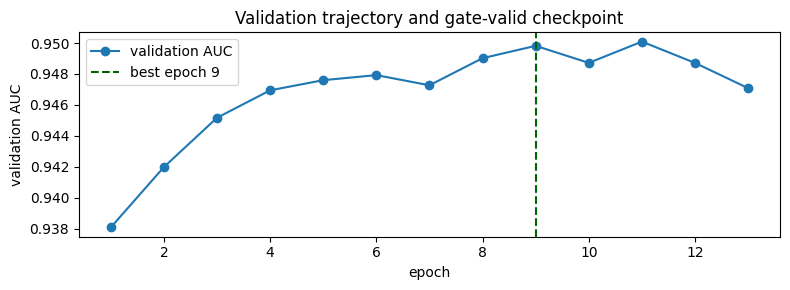

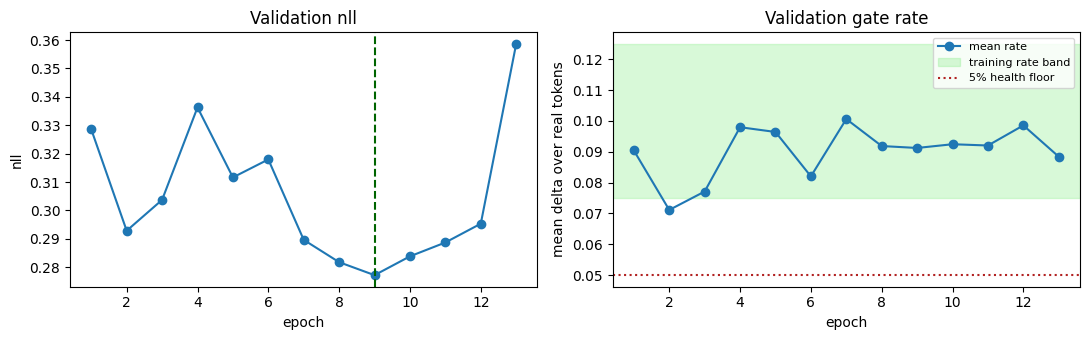

Restored epoch 9: validation nll=0.277218
Restored validation gate: eligible


,epoch,train_loss,train_nll,train_kl_scaled,train_p1,train_p2_statistic,effective_lambda_p1,effective_lambda_p2,selection_band_violation,train_selection_rate,...,val_brier,val_nll,val_ece,checkpoint_metric,checkpoint_value,checkpoint_window_open,gate_checkpoint_eligible,gate_eligibility_reason,is_unconstrained_best,is_best_checkpoint
0,1,0.536979,0.502880,0.108434,0.283506,0.092749,0.01,0.0,0.007235,0.092749,...,0.106096,0.328544,0.069873,nll,0.328544,False,False,waiting for checkpoint start epoch 3,True,False
1,2,0.465294,0.415399,0.108366,0.294052,0.096727,0.01,0.0,0.000776,0.096727,...,0.092710,0.292861,0.017996,nll,0.292861,False,False,waiting for checkpoint start epoch 3,True,False
2,3,0.478192,0.400211,0.108224,0.276177,0.092856,0.01,0.0,0.000660,0.092856,...,0.096836,0.303733,0.056630,nll,0.303733,True,True,eligible,False,True
3,4,0.485128,0.391261,0.107998,0.239827,0.094584,0.01,0.0,0.000850,0.094584,...,0.108269,0.336291,0.105015,nll,0.336291,True,True,eligible,False,False
4,5,0.495092,0.380648,0.107679,0.222880,0.095089,0.01,0.0,0.000679,0.095089,...,0.099669,0.311643,0.070783,nll,0.311643,True,True,eligible,False,False
5,6,0.491440,0.376796,0.107296,0.216156,0.095251,0.01,0.0,0.001251,0.095251,...,0.100499,0.317972,0.072859,nll,0.317972,True,True,eligible,False,False
6,7,0.488164,0.373483,0.106921,0.211435,0.094978,0.01,0.0,0.001682,0.094978,...,0.091797,0.289649,0.047631,nll,0.289649,True,True,eligible,True,True
7,8,0.477461,0.362911,0.106538,0.207144,0.095404,0.01,0.0,0.001895,0.095404,...,0.089315,0.281788,0.031233,nll,0.281788,True,True,eligible,True,True
8,9,0.472089,0.357939,0.106147,0.204045,0.095223,0.01,0.0,0.001784,0.095223,...,0.087949,0.277218,0.029248,nll,0.277218,True,True,eligible,True,True
9,10,0.458798,0.344338,0.105750,0.196225,0.094715,0.01,0.0,0.002466,0.094715,...,0.089603,0.283852,0.035085,nll,0.283852,True,True,eligible,False,False


In [17]:
# ================================================================
# 14. Train with validation-only, gate-eligible checkpointing
# ================================================================

model = BayesianAMICWD(
    embedding_matrix=embedding_matrix,
    hidden_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    prior_sigma_b=1.0,
    prior_sigma_beta=1.0,
    init_rho=-5.0,
    dropout=0.10,
    freeze_embeddings=FREEZE_EMBEDDINGS,
    selection_activation='sigmoid',
    max_len=MAX_LEN,
    use_positional_encoding=USE_POSITIONAL_ENCODING,
    aggregation_mode=AGGREGATION_MODE,
    aggregation_eps=AGGREGATION_EPS,
).to(DEVICE)

print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

if BEST_CHECKPOINT_PATH.exists():
    raise FileExistsError(
        f'Stale checkpoint already exists: {BEST_CHECKPOINT_PATH}. '
        'Change RUN_LABEL and rerun from the top.'
    )

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
n_train = len(train_ds)
history = []

best_value = np.inf if CHECKPOINT_MODE == 'min' else -np.inf
best_epoch = None
best_unconstrained_value = np.inf if CHECKPOINT_MODE == 'min' else -np.inf
best_unconstrained_epoch = None
eligible_epoch_count = 0
epochs_without_improvement = 0
stopped_early = False


def validation_improved(current, best):
    """Apply the configured direction and minimum meaningful change."""
    if not np.isfinite(current):
        return False
    if CHECKPOINT_MODE == 'min':
        return current < (best - CHECKPOINT_MIN_DELTA)
    return current > (best + CHECKPOINT_MIN_DELTA)


for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    component_sums = {}

    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss, logs = compute_loss(
            model, batch, epoch, n_train, train_mc_samples=TRAIN_MC_SAMPLES
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))
        for key, value in logs.items():
            component_sums[key] = component_sums.get(key, 0.0) + value

    n_batches = max(1, len(train_loader))
    component_means = {
        key: value / n_batches for key, value in component_sums.items()
    }

    # Deterministic validation only: no posterior sampling and no dropout noise.
    valid_point = deterministic_predict_loader(model, valid_loader)
    valid_metrics = binary_metrics_from_probs(valid_point['probs'], valid_point['labels'])
    valid_ece = expected_calibration_error(valid_point['probs'], valid_point['labels'])
    checkpoint_value = float(valid_metrics[CHECKPOINT_METRIC])

    unconstrained_improved = validation_improved(
        checkpoint_value, best_unconstrained_value
    )
    if unconstrained_improved:
        best_unconstrained_value = checkpoint_value
        best_unconstrained_epoch = epoch

    gate_is_healthy, gate_reason = gate_checkpoint_eligibility(valid_point)
    checkpoint_window_open = epoch >= CHECKPOINT_START_EPOCH
    checkpoint_eligible = checkpoint_window_open and gate_is_healthy
    if checkpoint_eligible:
        eligible_epoch_count += 1

    improved = checkpoint_eligible and validation_improved(checkpoint_value, best_value)
    if improved:
        best_value = checkpoint_value
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'run_seed': RUN_SEED,
            'run_mode': RUN_MODE,
            'checkpoint_metric': CHECKPOINT_METRIC,
            'checkpoint_mode': CHECKPOINT_MODE,
            'checkpoint_value': checkpoint_value,
            'validation_metrics': valid_metrics,
            'validation_ece': valid_ece,
            'validation_gate_diagnostics': scalar_prediction_diagnostics(valid_point),
            'gate_checkpoint_eligible': True,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'experiment_name': EXPERIMENT_NAME,
        }, BEST_CHECKPOINT_PATH)
    elif best_epoch is not None:
        # Before the first eligible checkpoint, patience remains at zero. Once a
        # valid checkpoint exists, any epoch without an eligible improvement counts.
        epochs_without_improvement += 1

    history.append({
        'epoch': epoch,
        'train_loss': float(np.mean(train_losses)),
        'train_nll': component_means.get('nll', np.nan),
        'train_kl_scaled': component_means.get('kl_scaled', np.nan),
        'train_p1': component_means.get('p1', np.nan),
        'train_p2_statistic': component_means.get('p2', np.nan),
        'effective_lambda_p1': LAMBDA_P1,
        'effective_lambda_p2': LAMBDA_P2,
        'selection_band_violation': component_means.get('selection_band_violation', np.nan),
        'train_selection_rate': component_means.get('selection_rate', np.nan),
        'train_denominator_mean': component_means.get('aggregation_denominator_mean', np.nan),
        'train_denominator_min': component_means.get('aggregation_denominator_min', np.nan),
        'stopword_delta': component_means.get('stopword_delta', np.nan),
        'boilerplate_delta': component_means.get('boilerplate_delta', np.nan),
        'content_delta': component_means.get('content_delta', np.nan),
        'val_selected_mass': valid_point['selected_mass_mean'],
        'val_selection_rate': valid_point['selection_rate_mean'],
        'val_selection_rate_q05': valid_point['selection_rate_q05'],
        'val_selection_rate_median': valid_point['selection_rate_median'],
        'val_selection_rate_q95': valid_point['selection_rate_q95'],
        'val_fraction_docs_below_health_min': valid_point['fraction_docs_below_gate_health_min'],
        'val_fraction_docs_above_health_max': valid_point['fraction_docs_above_gate_health_max'],
        'val_gate_contrast_ratio_median': valid_point['gate_contrast_ratio_median'],
        'val_gate_contrast_ratio_p10': valid_point['gate_contrast_ratio_p10'],
        'val_gate_max_minus_mean_median': valid_point['gate_max_minus_mean_median'],
        'val_delta_token_q90': valid_point['delta_token_q90'],
        'val_delta_token_q99': valid_point['delta_token_q99'],
        'val_denominator_mean': valid_point['aggregation_denominator_mean'],
        'val_denominator_min': valid_point['aggregation_denominator_min'],
        'val_acc': valid_metrics['acc'],
        'val_f1': valid_metrics['f1'],
        'val_auc': valid_metrics['auc'],
        'val_brier': valid_metrics['brier'],
        'val_nll': valid_metrics['nll'],
        'val_ece': valid_ece,
        'checkpoint_metric': CHECKPOINT_METRIC,
        'checkpoint_value': checkpoint_value,
        'checkpoint_window_open': checkpoint_window_open,
        'gate_checkpoint_eligible': checkpoint_eligible,
        'gate_eligibility_reason': (
            gate_reason if checkpoint_window_open
            else f'waiting for checkpoint start epoch {CHECKPOINT_START_EPOCH}'
        ),
        'is_unconstrained_best': unconstrained_improved,
        'is_best_checkpoint': improved,
    })

    # Persist every epoch so a Colab disconnect leaves a complete audit trail.
    pd.DataFrame(history).to_csv(OUTPUT_DIR / 'history.csv', index=False)

    if not checkpoint_window_open:
        checkpoint_status = f'warmup (checkpointing starts epoch {CHECKPOINT_START_EPOCH})'
    elif not gate_is_healthy:
        checkpoint_status = f'GATE REJECTED: {gate_reason}'
    elif improved:
        checkpoint_status = 'SAVED GATE-VALID BEST'
    else:
        checkpoint_status = f'eligible, no improvement ({epochs_without_improvement})'

    print(
        f"Epoch {epoch:02d} | loss={np.mean(train_losses):.4f} | "
        f"val_acc={valid_metrics['acc']:.4f} | val_auc={valid_metrics['auc']:.4f} | "
        f"val_nll={valid_metrics['nll']:.4f} | "
        f"rate={valid_point['selection_rate_mean']:.4f} | "
        f"contrast={valid_point['gate_contrast_ratio_median']:.2f} | "
        f"{checkpoint_status}"
    )

    if (
        best_epoch is not None
        and epoch >= MIN_EPOCHS_BEFORE_EARLY_STOPPING
        and epochs_without_improvement >= EARLY_STOPPING_PATIENCE
    ):
        stopped_early = True
        print(
            f'Early stopping after {EARLY_STOPPING_PATIENCE} epochs without '
            'an eligible validation improvement.'
        )
        break

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'history.csv', index=False)

# Keep the original AUC plot name for downstream compatibility.
plt.figure(figsize=(8, 3))
plt.plot(history_df['epoch'], history_df['val_auc'], marker='o', label='validation AUC')
if best_epoch is not None:
    plt.axvline(best_epoch, color='darkgreen', linestyle='--', label=f'best epoch {best_epoch}')
plt.xlabel('epoch')
plt.ylabel('validation AUC')
plt.title('Validation trajectory and gate-valid checkpoint')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'val_auc_curve.png', dpi=150)
plt.show()

# A dedicated diagnostic plot makes a collapse or uniform-gate failure obvious.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
metric_column = f'val_{CHECKPOINT_METRIC}'
axes[0].plot(history_df['epoch'], history_df[metric_column], marker='o')
if best_epoch is not None:
    axes[0].axvline(best_epoch, color='darkgreen', linestyle='--')
axes[0].set_title(f'Validation {CHECKPOINT_METRIC}')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel(CHECKPOINT_METRIC)

axes[1].plot(history_df['epoch'], history_df['val_selection_rate'], marker='o', label='mean rate')
if USE_SELECTION_RATE_BAND:
    axes[1].axhspan(
        SELECTION_RATE_BAND_LOW, SELECTION_RATE_BAND_HIGH,
        color='lightgreen', alpha=0.35, label='training rate band'
    )
axes[1].axhline(GATE_HEALTH_MIN_DOCUMENT_RATE, color='firebrick', linestyle=':', label='5% health floor')
axes[1].set_title('Validation gate rate')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('mean delta over real tokens')
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'validation_checkpoint_and_gate_curve.png', dpi=150)
plt.show()

if not BEST_CHECKPOINT_PATH.exists():
    pd.DataFrame([{
        'status': 'no_gate_eligible_checkpoint',
        'run_mode': RUN_MODE,
        'run_seed': RUN_SEED,
        'epochs_completed': int(history_df['epoch'].max()),
        'eligible_epoch_count': eligible_epoch_count,
        'best_unconstrained_epoch': best_unconstrained_epoch,
        'best_unconstrained_value': best_unconstrained_value,
        'evaluation_scope': 'exploratory_reuse_of_previously_inspected_project_test',
        'test_opened': False,
    }]).to_csv(OUTPUT_DIR / 'checkpoint_summary.csv', index=False)
    raise RuntimeError(
        'No gate-eligible validation checkpoint was produced. Test remains unopened. '
        'Inspect history.csv and validation_checkpoint_and_gate_curve.png; do not '
        'relax the gate rules after looking at test results.'
    )

try:
    best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
except TypeError:
    best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(best_checkpoint['model_state_dict'])
best_epoch = int(best_checkpoint['epoch'])
best_value = float(best_checkpoint['checkpoint_value'])

# Recompute validation diagnostics after restoration and assert the gate before the
# next cell is allowed to open the test CSV.
restored_valid_point = deterministic_predict_loader(model, valid_loader)
restored_gate_healthy, restored_gate_reason = gate_checkpoint_eligibility(restored_valid_point)
if USE_GATE_VALID_CHECKPOINT and not restored_gate_healthy:
    raise RuntimeError(
        'Restored checkpoint failed its validation gate-health assertion: '
        + restored_gate_reason
    )

pd.DataFrame([{
    'split': 'valid',
    **scalar_prediction_diagnostics(restored_valid_point),
    'gate_checkpoint_eligible': restored_gate_healthy,
    'gate_eligibility_reason': restored_gate_reason,
}]).to_csv(OUTPUT_DIR / 'restored_validation_gate_health.csv', index=False)

print(f'Restored epoch {best_epoch}: validation {CHECKPOINT_METRIC}={best_value:.6f}')
print('Restored validation gate:', restored_gate_reason)

checkpoint_summary = pd.DataFrame([{
    'status': 'restored_gate_valid_checkpoint',
    'run_mode': RUN_MODE,
    'run_seed': RUN_SEED,
    'best_epoch': best_epoch,
    'checkpoint_metric': CHECKPOINT_METRIC,
    'checkpoint_mode': CHECKPOINT_MODE,
    'best_validation_value': best_value,
    'best_unconstrained_epoch': best_unconstrained_epoch,
    'best_unconstrained_value': best_unconstrained_value,
    'epochs_completed': int(history_df['epoch'].max()),
    'eligible_epoch_count': eligible_epoch_count,
    'stopped_early': stopped_early,
    'validation_only_selection': True,
    'gate_valid_selection': USE_GATE_VALID_CHECKPOINT,
    'restored_validation_selection_rate': restored_valid_point['selection_rate_mean'],
    'restored_validation_fraction_docs_below_health_min': restored_valid_point['fraction_docs_below_gate_health_min'],
    'restored_validation_fraction_docs_above_health_max': restored_valid_point['fraction_docs_above_gate_health_max'],
    'restored_validation_median_contrast_ratio': restored_valid_point['gate_contrast_ratio_median'],
    'evaluation_scope': 'exploratory_reuse_of_previously_inspected_project_test',
    'project_test_previously_inspected': True,
    'test_used_for_selection': False,
}])
checkpoint_summary.to_csv(OUTPUT_DIR / 'checkpoint_summary.csv', index=False)

history_df

## Step 6 — Open the existing comparison holdout after a gate-valid winner

The test CSV has not been read, summarized, tokenized, or placed in a loader
before this point. The preceding cell asserts the restored checkpoint's
validation gate health; only then may this cell construct the holdout objects.
Because earlier Wine test results informed this repair, treat the resulting test
metrics as exploratory reuse—not as a fresh blind confirmatory estimate.

In [18]:
# ================================================================
# 15a. Load the existing exploratory comparison split after restoration
# ================================================================

test_path = DATA_DIR / 'wine_test.csv'
if not test_path.exists():
    raise FileNotFoundError(
        f'Missing {test_path}. Run 00_prepare_wine_data.ipynb first.'
    )

test_df = pd.read_csv(test_path)
test_df['text'] = test_df['text'].astype(str)
x_test, len_test, y_test = encode_dataframe(test_df)
sw_test, bp_test = build_penalty_masks(test_df, x_test)
test_ds = AMICTextDataset(x_test, y_test, len_test, sw_test, bp_test)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print('test:', test_df.shape, '| positive rate:', round(test_df['y'].mean(), 4))
print('test batches:', len(test_loader))
print('The restored checkpoint will now be evaluated on the existing exploratory comparison split.')

test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.


In [19]:
# ================================================================
# 15b. Final evaluation and gate-health diagnostics
# ================================================================

FINAL_MC_SAMPLES = 100

train_uncertainty, _ = posterior_predict_loader(
    model, train_eval_loader, n_samples=FINAL_MC_SAMPLES
)
valid_uncertainty, _ = posterior_predict_loader(
    model, valid_loader, n_samples=FINAL_MC_SAMPLES
)
test_uncertainty, _ = posterior_predict_loader(
    model, test_loader, n_samples=FINAL_MC_SAMPLES
)

train_probs = train_uncertainty['p_mean'].to_numpy()
valid_probs = valid_uncertainty['p_mean'].to_numpy()
test_probs = test_uncertainty['p_mean'].to_numpy()
y_train_true = train_uncertainty['y_true'].to_numpy()
y_valid_true = valid_uncertainty['y_true'].to_numpy()
y_test_true = test_uncertainty['y_true'].to_numpy()

train_uncertainty.to_csv(OUTPUT_DIR / 'train_document_uncertainty.csv', index=False)
valid_uncertainty.to_csv(OUTPUT_DIR / 'valid_document_uncertainty.csv', index=False)
test_uncertainty.to_csv(OUTPUT_DIR / 'test_document_uncertainty.csv', index=False)

# Posterior per-document rate/denominator summaries preserve the existing artifact
# name while adding explicit target-band and health-floor fields.
denominator_rows = []
for split_name, table in [
    ('train', train_uncertainty),
    ('valid', valid_uncertainty),
    ('test', test_uncertainty),
]:
    rates = table['selection_rate_mean']
    denominator_rows.append({
        'split': split_name,
        'selected_mass_mean': table['selected_mass_mean'].mean(),
        'selection_rate_mean': rates.mean(),
        'selection_rate_q05': rates.quantile(0.05),
        'selection_rate_median': rates.quantile(0.50),
        'selection_rate_q95': rates.quantile(0.95),
        'selection_rate_min': rates.min(),
        'aggregation_denominator_mean': table['aggregation_denominator_mean'].mean(),
        'aggregation_denominator_min': table['aggregation_denominator_mean'].min(),
        # Compatibility column: "floor" now means the separate 5% health floor.
        'fraction_selection_rate_below_floor': (
            rates < GATE_HEALTH_MIN_DOCUMENT_RATE
        ).mean(),
        'fraction_selection_rate_below_training_band': (
            rates < SELECTION_RATE_BAND_LOW
        ).mean(),
        'fraction_selection_rate_above_training_band': (
            rates > SELECTION_RATE_BAND_HIGH
        ).mean(),
    })

selection_denominator_diagnostics = pd.DataFrame(denominator_rows)
selection_denominator_diagnostics.to_csv(
    OUTPUT_DIR / 'selection_denominator_diagnostics.csv', index=False
)

# One deterministic pass per split supplies token-level quantiles and contrast.
point_predictions = {
    'train': deterministic_predict_loader(model, train_eval_loader),
    'valid': deterministic_predict_loader(model, valid_loader),
    'test': deterministic_predict_loader(model, test_loader),
}
gate_health_rows = []
for split_name, prediction in point_predictions.items():
    health_pass, health_reason = gate_checkpoint_eligibility(prediction)
    gate_health_rows.append({
        'split': split_name,
        **scalar_prediction_diagnostics(prediction),
        'passes_preregistered_gate_health': health_pass,
        'gate_health_reason': health_reason,
        'used_for_checkpoint_selection': split_name == 'valid',
    })

gate_health_diagnostics = pd.DataFrame(gate_health_rows)
gate_health_diagnostics.to_csv(
    OUTPUT_DIR / 'gate_health_diagnostics.csv', index=False
)

print('Posterior selection/denominator diagnostics:')
display(selection_denominator_diagnostics)
print('Deterministic token-level gate diagnostics:')
display(gate_health_diagnostics)
print(
    'Interpret delta as a soft gate score. Passing these diagnostics does not '
    'make it a calibrated human-rationale probability.'
)

test_uncertainty.head()

Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,2.987437,0.091607,0.069042,0.089755,0.120178,0.033158,2.987438,0.550270,0.0006,0.1250,0.03384
1,valid,2.986299,0.091462,0.070048,0.089716,0.119454,0.051267,2.986300,0.675858,0.0000,0.1180,0.03300
2,test,2.983014,0.091584,0.069168,0.089728,0.120026,0.040724,2.983015,0.713337,0.0009,0.1249,0.03190


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,2.978432,0.091330,0.068857,0.089482,0.119974,0.0006,0.004720,2.978433,0.550786,...,0.365087,0.001365,0.301460,2.629568,3.198137,0.190364,25000,True,eligible,False
1,valid,2.979261,0.091250,0.069795,0.089453,0.119561,0.0000,0.003667,2.979262,0.666440,...,0.366570,0.001344,0.300868,2.641073,3.193569,0.190284,3000,True,eligible,True
2,test,2.972073,0.091247,0.068860,0.089368,0.119661,0.0009,0.004400,2.972074,0.700344,...,0.363305,0.001250,0.300559,2.632560,3.201088,0.190328,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.


,y_true,p_mean,ci95_lo,ci95_hi,ci_width,var,entropy,bald,prob1,selected_mass_mean,selection_rate_mean,aggregation_denominator_mean,label_by_mean
0,0,0.499911,0.460853,0.549802,0.088949,0.000655,0.693147,0.001311,0.45,2.224759,0.069524,2.224760,0
1,1,0.862129,0.837764,0.883188,0.045424,0.000176,0.401080,0.000743,1.00,4.333085,0.111105,4.333086,1
2,1,0.987112,0.984174,0.989738,0.005564,0.000002,0.068887,0.000082,1.00,3.492043,0.074299,3.492043,1
3,1,0.979762,0.975725,0.983616,0.007891,0.000004,0.098962,0.000113,1.00,2.559961,0.071110,2.559962,1
4,0,0.951075,0.942415,0.958597,0.016182,0.000017,0.195339,0.000181,1.00,3.466228,0.080610,3.466228,1


In [20]:
# ================================================================
# 16. Validation-tuned decision thresholds
# ================================================================

# The default 0.5 threshold is not always optimal for accuracy or F1.
# Following the protocol from the wine Word2Vec analysis, we choose the threshold on
# the VALIDATION split and then apply that frozen choice to the TEST split.
# AUC is unaffected by this (it is threshold-free by construction).

# Candidate thresholds from 0.05 to 0.95 in small steps.
thresholds = np.arange(0.05, 0.951, 0.005)

# Evaluate validation accuracy and F1 at every candidate threshold.
valid_accs, valid_f1s = [], []
for t in thresholds:
    pred = (valid_probs >= t).astype(int)
    valid_accs.append((pred == y_valid_true).mean())
    valid_f1s.append(f1_score(y_valid_true, pred, zero_division=0))

# Pick the thresholds that maximize validation accuracy and validation F1.
best_acc_threshold = float(thresholds[int(np.argmax(valid_accs))])
best_f1_threshold = float(thresholds[int(np.argmax(valid_f1s))])
print('Best validation-accuracy threshold:', round(best_acc_threshold, 3))
print('Best validation-F1 threshold      :', round(best_f1_threshold, 3))


def test_metrics_at(threshold):
    """Compute test accuracy and F1 at a given decision threshold."""
    pred = (test_probs >= threshold).astype(int)
    return {'threshold': round(float(threshold), 3),
            'test_acc': (pred == y_test_true).mean(),
            'test_f1': f1_score(y_test_true, pred, zero_division=0)}


# Report test performance at the default and both tuned thresholds.
threshold_rows = [
    {'rule': 'default 0.5', **test_metrics_at(0.5)},
    {'rule': 'tuned by valid acc', **test_metrics_at(best_acc_threshold)},
    {'rule': 'tuned by valid F1', **test_metrics_at(best_f1_threshold)},
]
threshold_df = pd.DataFrame(threshold_rows)

# Save the threshold analysis next to the other outputs.
threshold_df.to_csv(OUTPUT_DIR / 'threshold_tuning.csv', index=False)

# Display the comparison.
threshold_df

Best validation-accuracy threshold: 0.53
Best validation-F1 threshold      : 0.455


,rule,threshold,test_acc,test_f1
0,default 0.5,0.500,0.8749,0.824273
1,tuned by valid acc,0.530,0.8765,0.823898
2,tuned by valid F1,0.455,0.8720,0.823497


In [21]:
# ================================================================
# 16. Is the uncertainty informative? Wrong vs. correct predictions
# ================================================================

# Mark which test predictions are wrong at the posterior-mean threshold of 0.5.
wrong = (test_uncertainty['label_by_mean'] != test_uncertainty['y_true'])

# Compare mean entropy and credible-interval width between wrong and correct predictions.
summary = pd.DataFrame({
    'wrong_mean': test_uncertainty.loc[wrong, ['entropy', 'ci_width', 'var', 'bald']].mean(),
    'correct_mean': test_uncertainty.loc[~wrong, ['entropy', 'ci_width', 'var', 'bald']].mean(),
})

# Add the wrong-to-correct ratio; values well above 1 mean uncertainty is informative.
summary['ratio_wrong_over_correct'] = summary['wrong_mean'] / summary['correct_mean']

# Save the diagnostic table.
summary.to_csv(OUTPUT_DIR / 'uncertainty_wrong_vs_correct.csv')

# Display it in the notebook.
summary

,wrong_mean,correct_mean,ratio_wrong_over_correct
entropy,0.526364,0.206718,2.546290
ci_width,0.073643,0.025610,2.875565
var,0.000444,0.000115,3.868836
bald,0.001084,0.000379,2.860161


In [22]:
# ================================================================
# 17. Word-level posterior uncertainty for one test sentence
# ================================================================

# Number of posterior samples for the word-level analysis.
WORD_MC_SAMPLES = 100

# Pick one test sentence to explain (change this index to explore other examples).
EXAMPLE_INDEX = 0

# Get the encoded ids of the chosen sentence as a batch of size 1.
example_ids = torch.tensor(x_test[EXAMPLE_INDEX:EXAMPLE_INDEX + 1], dtype=torch.long).to(DEVICE)

# Print the raw sentence and its true label.
print('Sentence:', test_df['text'].iloc[EXAMPLE_INDEX])
print('True label:', int(test_df['y'].iloc[EXAMPLE_INDEX]), '(1 = positive)')

# Collect per-sample word-level quantities without gradients.
delta_samples, z_samples, gated_samples, raw_samples = [], [], [], []
with torch.no_grad():
    # Eval mode turns dropout off so only (b, beta) sampling drives the variation.
    model.eval()
    for _ in range(WORD_MC_SAMPLES):
        # One forward pass = one posterior sample.
        out = model(example_ids, sample=True)
        # All four arrays must receive every posterior draw.
        delta_samples.append(out['delta'][0].cpu().numpy())
        # word_logit is the normalized additive contribution in this variant.
        z_samples.append(out['word_logit'][0].cpu().numpy())
        # gated_word_score is the legacy numerator delta * raw sentiment.
        gated_samples.append(out['gated_word_score'][0].cpu().numpy())
        raw_samples.append(out['raw_word_sentiment'][0].cpu().numpy())

# Stack to arrays of shape [S, MAX_LEN].
delta_samples = np.stack(delta_samples)
z_samples = np.stack(z_samples)
gated_samples = np.stack(gated_samples)
raw_samples = np.stack(raw_samples)

# The real (unpadded) length of this sentence.
real_len = int(len_test[EXAMPLE_INDEX])

# Build one row per real token with posterior summaries.
rows = []
for j in range(real_len):
    rows.append({
        'position': j,
        'word': id_to_word.get(int(x_test[EXAMPLE_INDEX, j]), '<UNK>'),
        'delta_mean': delta_samples[:, j].mean(),
        'delta_sd': delta_samples[:, j].std(),
        'delta_ge_0p5_frequency': (delta_samples[:, j] >= 0.5).mean(),
        'z_mean': z_samples[:, j].mean(),
        'gated_score_mean': gated_samples[:, j].mean(),
        'z_sd': z_samples[:, j].std(),
        'z_ci95_lo': np.quantile(z_samples[:, j], 0.025),
        'z_ci95_hi': np.quantile(z_samples[:, j], 0.975),
        'p_z_positive': (z_samples[:, j] > 0).mean(),
    })

# delta is a soft gate score; the 0.5 frequency is a diagnostic, not a calibrated rationale label.
# Sort tokens by absolute mean contribution so the strongest words appear first.
word_table = pd.DataFrame(rows).sort_values('z_mean', key=np.abs, ascending=False)

# Save the word-level table for the paper.
word_table.to_csv(OUTPUT_DIR / 'example_word_uncertainty.csv', index=False)

# Display the top rows.
word_table.head(15)

Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


,position,word,delta_mean,delta_sd,delta_ge_0p5_frequency,z_mean,gated_score_mean,z_sd,z_ci95_lo,z_ci95_hi,p_z_positive
7,7,floral,0.224601,0.021924,0.0,0.480753,1.076097,0.012421,0.454213,0.502190,1.0
17,17,stays,0.266792,0.024565,0.0,-0.357422,-0.799817,0.013296,-0.382791,-0.331230,0.0
5,5,plum,0.240463,0.022972,0.0,0.324538,0.726181,0.012585,0.296488,0.343052,1.0
8,8,notes,0.249634,0.023529,0.0,-0.301721,-0.675349,0.012368,-0.326367,-0.278523,0.0
18,18,balanced,0.177057,0.018278,0.0,-0.261041,-0.584770,0.009016,-0.280129,-0.244193,0.0
12,12,vibrant,0.199408,0.020058,0.0,0.230869,0.516852,0.009960,0.210034,0.247829,1.0
4,4,cherry,0.178372,0.018401,0.0,-0.064070,-0.143628,0.008655,-0.082579,-0.048427,0.0
3,3,displaying,0.044481,0.005354,0.0,-0.044699,-0.100264,0.002979,-0.050380,-0.039700,0.0
1,1,rich,0.233393,0.022483,0.0,-0.033381,-0.074876,0.011318,-0.056335,-0.011282,0.0
23,23,finish,0.038102,0.004619,0.0,0.013922,0.031187,0.002002,0.010354,0.017868,1.0


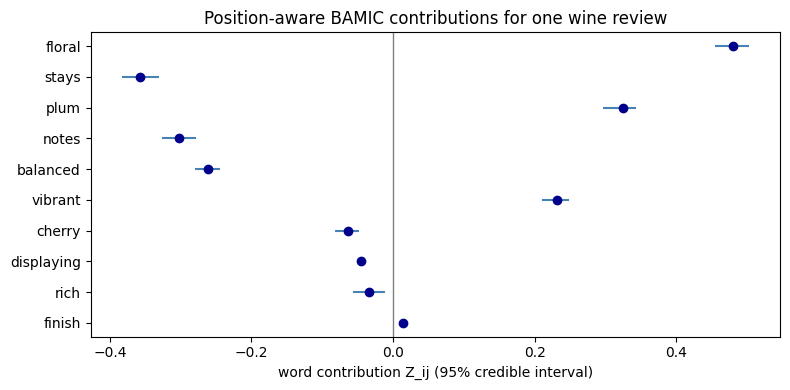

In [23]:
# ================================================================
# 18. Plot posterior intervals for the word contributions
# ================================================================

# Take the ten words with the largest absolute mean contribution.
top = word_table.head(10).iloc[::-1]

# Draw a horizontal interval plot: one line per word.
plt.figure(figsize=(8, 4))
# The horizontal line spans the 95% credible interval of each word's contribution.
plt.hlines(y=range(len(top)), xmin=top['z_ci95_lo'], xmax=top['z_ci95_hi'], color='steelblue')
# The dot marks the posterior mean contribution.
plt.plot(top['z_mean'], range(len(top)), 'o', color='darkblue')
# A vertical line at zero separates negative from positive contributions.
plt.axvline(0.0, color='gray', linewidth=1)
# Label each row with its word.
plt.yticks(range(len(top)), top['word'])
plt.xlabel('word contribution Z_ij (95% credible interval)')
plt.title('Position-aware BAMIC contributions for one wine review')
plt.tight_layout()
# Save the figure into the output folder for the paper.
plt.savefig(OUTPUT_DIR / 'example_word_contribution_intervals.png', dpi=150)
plt.show()

In [24]:
# ================================================================
# 19. Corpus-level word sentiment table (validation split)
# ================================================================

# Number of posterior samples per batch for the corpus scan.
CORPUS_MC_SAMPLES = 20

# Accumulate per-word statistics across the validation split.
word_stats = {}

with torch.no_grad():
    # Eval mode keeps dropout off.
    model.eval()
    # Walk over validation batches.
    for batch in valid_loader:
        # Move ids to the GPU.
        input_ids = batch['input_ids'].to(DEVICE)
        # Average delta and Z over posterior samples for this batch.
        delta_sum = torch.zeros(input_ids.shape, dtype=torch.float32)
        z_sum = torch.zeros(input_ids.shape, dtype=torch.float32)
        for _ in range(CORPUS_MC_SAMPLES):
            out = model(input_ids, sample=True)
            delta_sum += out['delta'].cpu()
            z_sum += out['word_logit'].cpu()
        delta_mean = (delta_sum / CORPUS_MC_SAMPLES).numpy()
        z_mean = (z_sum / CORPUS_MC_SAMPLES).numpy()
        # Accumulate statistics per vocabulary word.
        ids = input_ids.cpu().numpy()
        for i in range(ids.shape[0]):
            for j in range(ids.shape[1]):
                # Skip padding.
                if ids[i, j] == 0:
                    break
                word = id_to_word.get(int(ids[i, j]), '<UNK>')
                stats = word_stats.setdefault(word, {'count': 0, 'delta_sum': 0.0, 'z_sum': 0.0})
                stats['count'] += 1
                stats['delta_sum'] += float(delta_mean[i, j])
                stats['z_sum'] += float(z_mean[i, j])

# Convert the accumulated statistics into a table (words seen at least 5 times).
corpus_rows = []
for word, stats in word_stats.items():
    if stats['count'] >= 5:
        corpus_rows.append({
            'word': word,
            'count': stats['count'],
            'delta_mean': stats['delta_sum'] / stats['count'],
            'z_mean': stats['z_sum'] / stats['count'],
        })

# Sort by absolute average contribution so the strongest sentiment words appear first.
corpus_table = pd.DataFrame(corpus_rows).sort_values('z_mean', key=np.abs, ascending=False)

# Count how many of the top-100 words are penalized stopwords (contamination check).
top100 = corpus_table.head(100)
stopword_contamination = int(top100['word'].isin(STOPWORD_PENALTY_WORDS).sum())
print('Stopword contamination in top-100 corpus words:', stopword_contamination)

# Save the corpus-level table for the paper.
corpus_table.to_csv(OUTPUT_DIR / 'corpus_word_sentiment.csv', index=False)

# Display the strongest 20 words.
corpus_table.head(20)

Stopword contamination in top-100 corpus words: 0


,word,count,delta_mean,z_mean
207,simple,21,0.257805,-0.852294
1254,quick,5,0.158495,-0.690115
389,easygoing,18,0.233793,-0.675429
1143,shadings,5,0.213324,-0.623093
306,straightforward,29,0.201189,-0.602699
425,light,332,0.246617,-0.567535
378,flint,5,0.203818,-0.543037
708,chive,10,0.216728,-0.517439
995,inky,5,0.248877,-0.517407
670,awkward,6,0.282888,-0.516377


## Step 7 — Save artifacts, then use the preregistered comparison protocol

The notebook preserves the existing CSV/PNG/PT artifact family and adds
`gate_health_diagnostics.csv`, `restored_validation_gate_health.csv`, the
matched-seed plan, and gate-aware checkpoint provenance.

Before treating the selector as recovered, verify that the validation row:

- has mean rate between 5% and 15%;
- has no more than 10% of documents below the 5% health floor;
- has no more than 10% of documents above the 15% health ceiling;
- has median within-document `max(delta) / mean(delta)` at least 1.5; and
- says `passes_preregistered_gate_health = True`.

For the checkpoint-only ablation, rerun from a fresh runtime with
`RUN_MODE = 'checkpoint_only_legacy'` and the **same seed**. Repeat both modes
for all five values in `MATCHED_SEED_PLAN`; do not choose seeds based on test
performance. A later 5%/10%/15% evidence-budget sensitivity study should use
the same protocol and new run labels.

In [25]:
# ================================================================
# 22. Save final metrics, configuration, environment, and best weights
# ================================================================

final_metric_rows = []
for split_name, probs, labels in [
    ('train', train_probs, y_train_true),
    ('valid', valid_probs, y_valid_true),
    ('test', test_probs, y_test_true),
]:
    metrics = binary_metrics_from_probs(probs, labels)
    ece = expected_calibration_error(probs, labels)
    final_metric_rows.append({
        'split': split_name,
        'run_mode': RUN_MODE,
        'run_seed': RUN_SEED,
        'best_epoch': best_epoch,
        'evaluation_scope': 'exploratory_reuse_of_previously_inspected_project_test',
        **metrics,
        'ece': ece,
    })
    print(split_name, {k: round(v, 4) for k, v in metrics.items()}, 'ece=', round(ece, 4))

pd.DataFrame(final_metric_rows).to_csv(OUTPUT_DIR / 'final_metrics.csv', index=False)

pd.DataFrame([{
    'experiment_name': EXPERIMENT_NAME,
    'run_mode': RUN_MODE,
    'run_label': RUN_LABEL,
    'run_seed': RUN_SEED,
    'matched_seed_plan': ','.join(str(seed) for seed in MATCHED_SEED_PLAN),
    'evaluation_scope': 'exploratory_reuse_of_previously_inspected_project_test',
    'project_test_previously_inspected': True,
    'freeze_embeddings': FREEZE_EMBEDDINGS,
    'epochs': ABLATION_EPOCHS,
    'num_heads': NUM_HEADS,
    'lambda_boilerplate': LAMBDA_BOILERPLATE,
    'lambda_stopword': LAMBDA_STOPWORD,
    'stopword_warmup_epochs': STOPWORD_WARMUP_EPOCHS,
    'learning_rate': BAMIC_LEARNING_RATE,
    'max_len': MAX_LEN,
    'batch_size': BATCH_SIZE,
    'use_positional_encoding': USE_POSITIONAL_ENCODING,
    'position_encoding_type': POSITION_ENCODING_TYPE,
    'aggregation_mode': AGGREGATION_MODE,
    'aggregation_eps': AGGREGATION_EPS,
    'lambda_p1': LAMBDA_P1,
    'lambda_p2_effective': LAMBDA_P2,
    'lambda_p2_legacy': LEGACY_LAMBDA_P2,
    'lambda_p3': LAMBDA_P3,
    'use_selection_rate_band': USE_SELECTION_RATE_BAND,
    'selection_rate_band_center': SELECTION_RATE_BAND_CENTER,
    'selection_rate_band_low': SELECTION_RATE_BAND_LOW,
    'selection_rate_band_high': SELECTION_RATE_BAND_HIGH,
    'lambda_selection_rate_band': LAMBDA_SELECTION_RATE_BAND,
    'use_gate_valid_checkpoint': USE_GATE_VALID_CHECKPOINT,
    'gate_health_mean_rate_low': GATE_HEALTH_MEAN_RATE_LOW,
    'gate_health_mean_rate_high': GATE_HEALTH_MEAN_RATE_HIGH,
    'gate_health_min_document_rate': GATE_HEALTH_MIN_DOCUMENT_RATE,
    'gate_health_max_fraction_docs_below_min': GATE_HEALTH_MAX_FRACTION_DOCS_BELOW_MIN,
    'gate_health_max_document_rate': GATE_HEALTH_MAX_DOCUMENT_RATE,
    'gate_health_max_fraction_docs_above_max': GATE_HEALTH_MAX_FRACTION_DOCS_ABOVE_MAX,
    'gate_contrast_min_length': GATE_CONTRAST_MIN_LENGTH,
    'gate_health_min_median_contrast_ratio': GATE_HEALTH_MIN_MEDIAN_CONTRAST_RATIO,
    'checkpoint_metric': CHECKPOINT_METRIC,
    'checkpoint_mode': CHECKPOINT_MODE,
    'checkpoint_min_delta': CHECKPOINT_MIN_DELTA,
    'checkpoint_start_epoch': CHECKPOINT_START_EPOCH,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'min_epochs_before_early_stopping': MIN_EPOCHS_BEFORE_EARLY_STOPPING,
    'best_epoch': best_epoch,
    'best_validation_value': best_value,
    'best_acc_threshold': best_acc_threshold,
    'best_f1_threshold': best_f1_threshold,
    'python_version': __import__('sys').version.split()[0],
    'torch_version': torch.__version__,
    'cuda_version': torch.version.cuda,
    'device_name': (
        torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
    ),
}]).to_csv(OUTPUT_DIR / 'run_config.csv', index=False)

# The legacy state-dict filename is kept for existing comparison scripts. The full
# gate-valid checkpoint additionally contains optimizer and validation provenance.
torch.save(model.state_dict(), OUTPUT_DIR / 'bamic_wine_state_dict.pt')

pd.DataFrame([{
    'run_complete': True,
    'run_mode': RUN_MODE,
    'run_seed': RUN_SEED,
    'best_epoch': best_epoch,
    'output_dir': str(OUTPUT_DIR),
    'evaluation_scope': 'exploratory_reuse_of_previously_inspected_project_test',
    'test_used_for_selection': False,
}]).to_csv(OUTPUT_DIR / 'run_completion.csv', index=False)

print('Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:')
print(OUTPUT_DIR)

train {'acc': 0.893, 'f1': 0.8487, 'auc': np.float64(0.9617), 'brier': np.float64(0.0756), 'nll': 0.242} ece= 0.0267
valid {'acc': 0.875, 'f1': 0.8227, 'auc': np.float64(0.9498), 'brier': np.float64(0.0879), 'nll': 0.2772} ece= 0.0292
test {'acc': 0.8749, 'f1': 0.8243, 'auc': np.float64(0.9505), 'brier': np.float64(0.0869), 'nll': 0.2757} ece= 0.0278
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_v1
